In [ ]:
# ============================================================
# ANÁLISIS DE MORBILIDAD ATENDIDA EN BOGOTÁ — RIPS 2022–2024
# Fuente: Secretaría Distrital de Salud — Datos Abiertos Bogotá
# Herramientas: Python · SQL · Excel · Power BI
# ============================================================

# Instalación de librerías
!pip install pandas numpy matplotlib seaborn sqlalchemy openpyxl scikit-learn -q

# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Entorno configurado correctamente')
print(f'📦 pandas {pd.__version__} | numpy {np.__version__}')

✅ Entorno configurado correctamente
📦 pandas 2.2.2 | numpy 2.0.2


In [ ]:
# ============================================================
# CARGA Y LIMPIEZA — RIPS BOGOTÁ 2022–2025
# ============================================================
import requests
from io import StringIO
import time

urls = {
    '2022_1': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/be614a33-b145-4e84-9f57-52b99d01adc8/download/descargable_rips_2022_1_180326.csv',
    '2022_2': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/7fa34c8e-f3e7-4c76-9421-aeecbaeb67fa/download/descargable_rips_2022_2_180326.csv',
    '2023_1': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/b854b7ff-2496-43ad-9918-777ca0a4e1b0/download/descargable_rips_2023_1_180326.csv',
    '2023_2': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/7f0b1c38-8513-473b-b706-779b171a57d2/download/descargable_rips_2023_2_180326.csv',
    '2024_1': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/aad2fb83-a2af-4729-92c0-6ea821a65166/download/descargable_rips_2024_1_180326.csv',
    '2024_2': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/c92ce8b5-0403-4ae1-bc72-ba7b8ee72099/download/descargable_rips_2024_2_180326.csv',
    '2024_3': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/8c9a440f-a024-4caf-95f5-c43654b98a3d/download/descargable_rips_2024_3_180326.csv',
    '2025_1': 'https://datosabiertos.bogota.gov.co/dataset/3176e77f-0b57-4d1a-ade5-e85cd7516915/resource/a4df895a-06a0-4f78-abaa-da661d90eac6/download/descargable_rips_2025_180326.csv',
}

def descargar_con_reintento(nombre, url, intentos=3, timeout=120):
    for i in range(intentos):
        try:
            print(f'⏳ {nombre} — intento {i+1}...')
            r = requests.get(url, timeout=timeout)
            r.raise_for_status()
            df = pd.read_csv(StringIO(r.content.decode('latin1')), sep=None, engine='python')
            df.columns = df.columns.str.replace('ï»¿', '', regex=False).str.strip()
            df = df.loc[:, ~df.columns.duplicated()]
            df['ANO_REAL'] = int(nombre.split('_')[0])
            df['archivo_origen'] = nombre
            print(f'✅ {nombre}: {df.shape[0]:,} filas')
            return df
        except Exception as e:
            print(f'⚠️ {nombre} intento {i+1} falló: {e}')
            time.sleep(10)
    print(f'❌ {nombre}: falló después de {intentos} intentos')
    return None

dfs = []
for nombre, url in urls.items():
    df_temp = descargar_con_reintento(nombre, url)
    if df_temp is not None:
        dfs.append(df_temp)

df_rips = pd.concat(dfs, ignore_index=True)

if 'ANO' in df_rips.columns:
    df_rips = df_rips.drop(columns=['ANO'])
df_rips = df_rips.rename(columns={'ANO_REAL': 'ANO'})

columnas_texto = ['prestador_localidad_nombre', 'tipo_atencion_nombre',
                  'dxPrincipal_agrupacion1_nombre', 'dxPrincipal_agrupacion2_nombre',
                  'administradora_consolidada', 'Sexo_Gen', 'Edad_Quiquenio',
                  'tipo_usuario_afiliacion']

for col in columnas_texto:
    df_rips[col] = (df_rips[col].astype(str)
                    .str.encode('latin1', errors='ignore')
                    .str.decode('utf-8', errors='ignore'))

df_rips = df_rips[~df_rips['prestador_localidad_nombre'].isin(['Sin Dato', 'Fuera de Bogotá', 'nan'])]

print(f'\n✅ Dataset listo: {df_rips.shape[0]:,} registros')
print(df_rips['ANO'].value_counts().sort_index())

⏳ 2022_1 — intento 1...
✅ 2022_1: 1,000,000 filas
⏳ 2022_2 — intento 1...
✅ 2022_2: 909,331 filas
⏳ 2023_1 — intento 1...
✅ 2023_1: 1,000,000 filas
⏳ 2023_2 — intento 1...
✅ 2023_2: 912,081 filas
⏳ 2024_1 — intento 1...
✅ 2024_1: 1,000,000 filas
⏳ 2024_2 — intento 1...
✅ 2024_2: 1,000,000 filas
⏳ 2024_3 — intento 1...
✅ 2024_3: 76,711 filas
⏳ 2025_1 — intento 1...
✅ 2025_1: 1,018,472 filas

✅ Dataset listo: 6,098,605 registros
ANO
2022    1681741
2023    1655144
2024    1765060
2025     996660
Name: count, dtype: int64


In [ ]:
# ============================================================
# VALIDACIÓN DE CALIDAD DE DATOS
# ============================================================

print('--- Forma del dataset ---')
print(df_rips.shape)

print('\n--- Tipos de datos ---')
print(df_rips.dtypes)

print('\n--- Valores nulos por columna ---')
print(df_rips.isnull().sum())

print('\n--- Duplicados exactos ---')
print(f'{df_rips.duplicated().sum():,} filas duplicadas')

print('\n--- Tipos de atención ---')
print(df_rips['tipo_atencion_nombre'].value_counts())

print('\n--- Sexo ---')
print(df_rips['Sexo_Gen'].value_counts())

print('\n--- Grupos de edad ---')
print(df_rips['Edad_Quiquenio'].value_counts().sort_index())

print('\n--- Tipo de afiliación ---')
print(df_rips['tipo_usuario_afiliacion'].value_counts())

print('\n--- Localidades (todas) ---')
print(df_rips['prestador_localidad_nombre'].value_counts())

print('\n--- Estadísticas de sum_atenciones ---')
print(df_rips['sum_atenciones'].describe())

print('\n--- Top 10 diagnósticos agrupación 1 ---')
print(df_rips['dxPrincipal_agrupacion1_nombre'].value_counts().head(10))

print('\n--- Diagnósticos agrupación 1 — valores raros (menos frecuentes) ---')
print(df_rips['dxPrincipal_agrupacion1_nombre'].value_counts().tail(10))

--- Forma del dataset ---
(6098605, 12)

--- Tipos de datos ---
Sexo_Gen                          object
Edad_Quiquenio                    object
tipo_usuario_afiliacion           object
prestador_localidad_codigo         int64
prestador_localidad_nombre        object
tipo_atencion_nombre              object
dxPrincipal_agrupacion1_nombre    object
dxPrincipal_agrupacion2_nombre    object
administradora_consolidada        object
sum_atenciones                     int64
ANO                                int64
archivo_origen                    object
dtype: object

--- Valores nulos por columna ---
Sexo_Gen                          0
Edad_Quiquenio                    0
tipo_usuario_afiliacion           0
prestador_localidad_codigo        0
prestador_localidad_nombre        0
tipo_atencion_nombre              0
dxPrincipal_agrupacion1_nombre    0
dxPrincipal_agrupacion2_nombre    0
administradora_consolidada        0
sum_atenciones                    0
ANO                               0

In [ ]:
# ============================================================
# CORRECCIÓN DE LOCALIDADES — UNIFICAR NOMBRES
# ============================================================

mapa_localidades = {
    'Usaqun': 'Usaquén',
    'San Cristbal': 'San Cristóbal',
    'Ciudad Bolivar': 'Ciudad Bolívar',
    'Los Mrtires': 'Los Mártires',
    'Antonio Nario': 'Antonio Nariño',
    'Santa Fé': 'Santa Fe',
    'Santa F': 'Santa Fe',
    'Fontibn': 'Fontibón',
    'Engativ': 'Engativá',
    'Fuera de Bogot': 'Fuera de Bogotá',
}

df_rips['prestador_localidad_nombre'] = df_rips['prestador_localidad_nombre'].replace(mapa_localidades)

# Eliminar "Fuera de Bogotá" — no es una localidad de la ciudad
df_rips = df_rips[df_rips['prestador_localidad_nombre'] != 'Fuera de Bogotá']

print('✅ Localidades unificadas')
print(f'📊 Registros finales: {df_rips.shape[0]:,}')
print(f'\n--- Localidades (20 esperadas) ---')
print(df_rips['prestador_localidad_nombre'].value_counts())
print(f'\n🔢 Número de localidades únicas: {df_rips["prestador_localidad_nombre"].nunique()}')

✅ Localidades unificadas
📊 Registros finales: 6,049,626

--- Localidades (20 esperadas) ---
prestador_localidad_nombre
Usaquén               818949
Suba                  680164
Chapinero             635906
Teusaquillo           606844
Kennedy               536640
Barrios Unidos        432345
Antonio Nariño        345128
Los Mártires          326201
Tunjuelito            273739
Puente Aranda         271738
Rafael Uribe Uribe    243703
Engativá              218526
San Cristóbal         217391
Fontibón              142735
Ciudad Bolívar         91603
Bosa                   75819
Santa Fe               60871
Usme                   48546
La Candelaria          22511
Sumapaz                  267
Name: count, dtype: int64

🔢 Número de localidades únicas: 20


In [ ]:
# ============================================================
# VALIDACIÓN PROFUNDA DEL DATASET
# ============================================================

print('--- 1. Consistencia por año y archivo de origen ---')
print(df_rips.groupby('ANO')['archivo_origen'].unique())

print('\n--- 2. sum_atenciones por tipo de atención (¿coherente?) ---')
print(df_rips.groupby('tipo_atencion_nombre')['sum_atenciones'].describe())

print('\n--- 3. ¿Hay sum_atenciones = 0 o negativos? ---')
print(f"Valores <= 0: {(df_rips['sum_atenciones'] <= 0).sum()}")

print('\n--- 4. Outliers extremos en sum_atenciones (top 10) ---')
print(df_rips.nlargest(10, 'sum_atenciones')[['ANO','prestador_localidad_nombre','tipo_atencion_nombre','dxPrincipal_agrupacion1_nombre','sum_atenciones']])

print('\n--- 5. Total de atenciones por año (suma de sum_atenciones) ---')
print(df_rips.groupby('ANO')['sum_atenciones'].sum())

print('\n--- 6. Registros por año y tipo de atención (¿está balanceado?) ---')
print(df_rips.groupby(['ANO','tipo_atencion_nombre']).size().unstack())

print('\n--- 7. ¿"Edad_Quiquenio" tiene valores raros / texto inesperado? ---')
print(sorted(df_rips['Edad_Quiquenio'].unique()))

print('\n--- 8. ¿"administradora_consolidada" tiene categorías raras? ---')
print(df_rips['administradora_consolidada'].value_counts().head(20))

print('\n--- 9. Códigos de localidad vs nombres — ¿1 a 1? ---')
print(df_rips.groupby('prestador_localidad_codigo')['prestador_localidad_nombre'].unique())

print('\n--- 10. Diagnóstico agrupación 2 — cantidad de categorías únicas ---')
print(f"Categorías únicas agrupación 1: {df_rips['dxPrincipal_agrupacion1_nombre'].nunique()}")
print(f"Categorías únicas agrupación 2: {df_rips['dxPrincipal_agrupacion2_nombre'].nunique()}")

--- 1. Consistencia por año y archivo de origen ---
ANO
2022            [2022_1, 2022_2]
2023            [2023_1, 2023_2]
2024    [2024_1, 2024_2, 2024_3]
2025                    [2025_1]
Name: archivo_origen, dtype: object

--- 2. sum_atenciones por tipo de atención (¿coherente?) ---
                          count       mean         std  min  25%  50%  75%  \
tipo_atencion_nombre                                                         
Consultas             4758193.0  20.636053  206.561915  1.0  1.0  3.0  8.0   
Hospitalizaciones      578214.0   2.703686    7.495345  1.0  1.0  1.0  2.0   
Urgencias              713219.0   3.312242   16.939648  1.0  1.0  1.0  2.0   

                          max  
tipo_atencion_nombre           
Consultas             54009.0  
Hospitalizaciones       719.0  
Urgencias              4022.0  

--- 3. ¿Hay sum_atenciones = 0 o negativos? ---
Valores <= 0: 0

--- 4. Outliers extremos en sum_atenciones (top 10) ---
          ANO prestador_localidad_nombre 

In [ ]:
# ============================================================
# DATASET SECUNDARIO — POBLACIÓN POR LOCALIDAD (DANE/SDP OFICIAL)
# ============================================================

url_poblacion = 'https://datosabiertos.bogota.gov.co/dataset/85bf790d-84d1-4eda-bd6f-40af62e71d95/resource/d1743cda-9ff9-4103-87ab-9c038f2f09a3/download/osb_demografia-poblacion-localidad.csv'

df_pob_raw = pd.read_csv(url_poblacion, sep=None, engine='python', encoding='latin1')

print('--- Forma del dataset ---')
print(df_pob_raw.shape)

print('\n--- Columnas ---')
print(list(df_pob_raw.columns))

print('\n--- Primeras filas ---')
print(df_pob_raw.head(10))

print('\n--- Tipos de datos ---')
print(df_pob_raw.dtypes)

--- Forma del dataset ---
(175956, 10)

--- Columnas ---
['ï»¿ANO', 'CODIGO_UPL', 'NOMBRE_UPL', 'SEXO', 'EDAD', 'ORDEN_MCV', 'CURSODEVIDA', 'ORDEN_GRUPO_EDAD', 'GRUPOEDAD', 'POBLACION']

--- Primeras filas ---
   ï»¿ANO  CODIGO_UPL NOMBRE_UPL     SEXO  EDAD  ORDEN_MCV       CURSODEVIDA  \
0    2005           1   SumapÃ¡z  Hombres     0          1  Primera Infancia   
1    2005           1   SumapÃ¡z  Hombres     1          1  Primera Infancia   
2    2005           1   SumapÃ¡z  Hombres     2          1  Primera Infancia   
3    2005           1   SumapÃ¡z  Hombres     3          1  Primera Infancia   
4    2005           1   SumapÃ¡z  Hombres     4          1  Primera Infancia   
5    2005           1   SumapÃ¡z  Hombres     5          1  Primera Infancia   
6    2005           1   SumapÃ¡z  Hombres     6          2          Infancia   
7    2005           1   SumapÃ¡z  Hombres     7          2          Infancia   
8    2005           1   SumapÃ¡z  Hombres     8          2          In

In [ ]:
# ============================================================
# DATASET SECUNDARIO — POBLACIÓN POR LOCALIDAD (DANE/SDP OFICIAL)
# ============================================================

url_poblacion = 'https://datosabiertos.bogota.gov.co/dataset/85bf790d-84d1-4eda-bd6f-40af62e71d95/resource/d1743cda-9ff9-4103-87ab-9c038f2f09a3/download/osb_demografia-poblacion-localidad.csv'

df_pob_raw = pd.read_csv(url_poblacion, sep=None, engine='python', encoding='latin1')
df_pob_raw.columns = df_pob_raw.columns.str.replace('ï»¿', '', regex=False).str.strip()

df_pob_raw['NOMBRE_UPL'] = (df_pob_raw['NOMBRE_UPL'].astype(str)
                             .str.encode('latin1', errors='ignore')
                             .str.decode('utf-8', errors='ignore'))

df_pob_filtrado = df_pob_raw[df_pob_raw['ANO'].isin([2022, 2023, 2024, 2025])].copy()

print(f'✅ Dataset población cargado: {df_pob_filtrado.shape[0]:,} filas')
print(f'Años disponibles: {sorted(df_pob_filtrado["ANO"].unique())}')
print(f'UPLs únicas: {df_pob_filtrado["NOMBRE_UPL"].nunique()}')

✅ Dataset población cargado: 22,704 filas
Años disponibles: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
UPLs únicas: 33


In [ ]:
# ============================================================
# FUSIÓN DE LOCALIDADES + REGENERAR POBLACIÓN + OPTIMIZAR + SQLite
# Santa Fe + La Candelaria + Los Mártires -> "Santa Fe (Centro)" (18 localidades)
# ============================================================

# --- 1. Fusionar localidades en df_rips (20 -> 18) ---
df_rips['prestador_localidad_nombre'] = df_rips['prestador_localidad_nombre'].replace({
    'Santa Fe': 'Santa Fe (Centro)',
    'La Candelaria': 'Santa Fe (Centro)',
    'Los Mártires': 'Santa Fe (Centro)'
})
print(f"Localidades en df_rips: {df_rips['prestador_localidad_nombre'].nunique()}")

# --- 2. Mapeo UPL -> Localidad (18) y regenerar df_poblacion ---
mapeo_upl_localidad = {
    'Sumapáz': 'Sumapaz',
    'Cuenca del Tunjuelo': 'Ciudad Bolívar',
    'Arborizadora': 'Ciudad Bolívar',
    'Lucero': 'Ciudad Bolívar',
    'Usme - Entrenubes': 'Usme',
    'Cerros Orientales': 'San Cristóbal',
    'Torca': 'Usaquén',
    'Britalia': 'Usaquén',
    'Toberín': 'Usaquén',
    'Usaquén': 'Usaquén',
    'Niza': 'Suba',
    'Suba': 'Suba',
    'Tibabuyes': 'Suba',
    'Rincón de Suba': 'Suba',
    'Engativá': 'Engativá',
    'Tabora': 'Engativá',
    'Fontibón': 'Fontibón',
    'Tintal': 'Kennedy',
    'Patio Bonito': 'Kennedy',
    'Kennedy': 'Kennedy',
    'Porvenir': 'Bosa',
    'Bosa': 'Bosa',
    'Edén': 'Rafael Uribe Uribe',
    'Rafael Uribe': 'Rafael Uribe Uribe',
    'Tunjuelito': 'Tunjuelito',
    'San Cristóbal': 'San Cristóbal',
    'Restrepo': 'Antonio Nariño',
    'Centro Histórico': 'Santa Fe (Centro)',
    'Chapinero': 'Chapinero',
    'Salitre': 'Barrios Unidos',
    'Puente Aranda': 'Puente Aranda',
    'Teusaquillo': 'Teusaquillo',
    'Barrios Unidos': 'Barrios Unidos',
}

df_pob_filtrado['localidad'] = df_pob_filtrado['NOMBRE_UPL'].map(mapeo_upl_localidad)
sin_mapear = df_pob_filtrado[df_pob_filtrado['localidad'].isna()]['NOMBRE_UPL'].unique()
print(f"UPL sin mapear: {sin_mapear}")

df_poblacion = df_pob_filtrado.groupby(['ANO', 'localidad'])['POBLACION'].sum().reset_index()
df_poblacion = df_poblacion.rename(columns={'ANO': 'ano'})
print(f"Localidades en df_poblacion: {df_poblacion['localidad'].nunique()}")

localidades_rips = set(df_rips['prestador_localidad_nombre'].unique())
localidades_pob = set(df_poblacion['localidad'].unique())
print(f"Sin coincidencia RIPS->Pob: {localidades_rips - localidades_pob}")
print(f"Sin coincidencia Pob->RIPS: {localidades_pob - localidades_rips}")

# --- 3. Optimizar memoria de df_rips ---
if 'prestador_localidad_codigo' in df_rips.columns:
    df_rips = df_rips.drop(columns=['prestador_localidad_codigo'])
if 'archivo_origen' in df_rips.columns:
    df_rips = df_rips.drop(columns=['archivo_origen'])

columnas_categoria = ['Sexo_Gen', 'Edad_Quiquenio', 'tipo_usuario_afiliacion',
                       'prestador_localidad_nombre', 'tipo_atencion_nombre',
                       'dxPrincipal_agrupacion1_nombre', 'dxPrincipal_agrupacion2_nombre',
                       'administradora_consolidada']
for col in columnas_categoria:
    df_rips[col] = df_rips[col].astype('category')

print(f"Memoria df_rips: {df_rips.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# --- 4. Crear base SQLite y guardar ambas tablas ---
engine = create_engine('sqlite:///morbilidad_bogota.db')

df_poblacion.to_sql('poblacion', engine, if_exists='replace', index=False)
print("Tabla poblacion guardada")

chunk_size = 500_000
total_filas = len(df_rips)
for i, start in enumerate(range(0, total_filas, chunk_size)):
    chunk = df_rips.iloc[start:start+chunk_size]
    chunk.to_sql('morbilidad', engine, if_exists='replace' if i == 0 else 'append', index=False)
    print(f"Bloque {i+1}: filas {start:,} a {min(start+chunk_size, total_filas):,}")

# --- 5. Verificación final ---
check_loc = pd.read_sql("SELECT DISTINCT prestador_localidad_nombre FROM morbilidad ORDER BY prestador_localidad_nombre", engine)
check_pob = pd.read_sql("SELECT DISTINCT localidad FROM poblacion ORDER BY localidad", engine)
test = pd.read_sql("SELECT COUNT(*) as total FROM morbilidad", engine)

print(f"\nLocalidades morbilidad: {len(check_loc)} | Localidades poblacion: {len(check_pob)}")
print(f"Total registros morbilidad: {test['total'][0]:,}")


Localidades en df_rips: 18
UPL sin mapear: []
Localidades en df_poblacion: 18
Sin coincidencia RIPS->Pob: set()
Sin coincidencia Pob->RIPS: set()
Memoria df_rips: 206.0 MB
Tabla poblacion guardada
Bloque 1: filas 0 a 500,000
Bloque 2: filas 500,000 a 1,000,000
Bloque 3: filas 1,000,000 a 1,500,000
Bloque 4: filas 1,500,000 a 2,000,000
Bloque 5: filas 2,000,000 a 2,500,000
Bloque 6: filas 2,500,000 a 3,000,000
Bloque 7: filas 3,000,000 a 3,500,000
Bloque 8: filas 3,500,000 a 4,000,000
Bloque 9: filas 4,000,000 a 4,500,000
Bloque 10: filas 4,500,000 a 5,000,000
Bloque 11: filas 5,000,000 a 5,500,000
Bloque 12: filas 5,500,000 a 6,000,000
Bloque 13: filas 6,000,000 a 6,049,626

Localidades morbilidad: 18 | Localidades poblacion: 18
Total registros morbilidad: 6,049,626


In [ ]:
# ============================================================
# ANÁLISIS DESCRIPTIVO — PREGUNTA 1
# Top 10 diagnósticos más frecuentes por año
# ============================================================

consulta1 = """
SELECT
    ANO,
    dxPrincipal_agrupacion1_nombre AS diagnostico,
    SUM(sum_atenciones) AS total_atenciones,
    COUNT(*) AS num_registros
FROM morbilidad
GROUP BY ANO, dxPrincipal_agrupacion1_nombre
ORDER BY ANO, total_atenciones DESC
"""

df_q1 = pd.read_sql(consulta1, engine)

# Top 10 por año
top10_por_ano = df_q1.groupby('ANO').head(10)

print('--- Top 10 diagnósticos por año ---')
print(top10_por_ano.to_string(index=False))

--- Top 10 diagnósticos por año ---
 ANO                                                                                        diagnostico  total_atenciones  num_registros
2022                      Personas En Contacto Con Los Servicios De Salud Para Investigacion Y Examenes           4467844          20521
2022                     Enfermedades De La Cavidad Bucal De Las Glandulas Salivales Y De Los Maxilares           3026585          43653
2022                                                                        Sintomas Y Signos Generales           2233278          53727
2022                                                                         Enfermedades Hipertensivas           1831220          11156
2022                                            Infecciones Agudas De Las Vias Respiratorias Superiores            807489          31753
2022  Trastornos De Los Musculos Oculares Del Movimiento Binocular De La Acomodacion Y De La Refraccion            799212           6613
2022 

In [ ]:
# ============================================================
# ANÁLISIS DESCRIPTIVO — PREGUNTA 2 (corregida)
# Localidades con mayor volumen de atenciones
# ============================================================

consulta2 = """
SELECT
    prestador_localidad_nombre AS localidad,
    SUM(sum_atenciones) AS total_atenciones,
    COUNT(*) AS num_registros,
    ROUND(SUM(sum_atenciones) * 1.0 / COUNT(*), 2) AS promedio_atenciones_registro
FROM morbilidad
GROUP BY prestador_localidad_nombre
ORDER BY total_atenciones DESC
"""

df_q2 = pd.read_sql(consulta2, engine)

print('--- Volumen de atenciones por localidad ---')
print(df_q2.to_string(index=False))

--- Volumen de atenciones por localidad ---
         localidad  total_atenciones  num_registros  promedio_atenciones_registro
              Suba          17503949         680164                         25.73
       Teusaquillo          11928104         606844                         19.66
           Usaquén          11757366         818949                         14.36
    Barrios Unidos          11529731         432345                         26.67
         Chapinero           9565619         635906                         15.04
           Kennedy           9232934         536640                         17.21
     Puente Aranda           6588771         271738                         24.25
    Antonio Nariño           5249363         345128                         15.21
        Tunjuelito           4195277         273739                         15.33
          Engativá           3502935         218526                         16.03
 Santa Fe (Centro)           3306768         409583   

In [ ]:
# ============================================================
# ANÁLISIS DESCRIPTIVO — PREGUNTA 3
# Evolución de la morbilidad por año
# ============================================================

consulta3 = """
SELECT
    ANO,
    SUM(sum_atenciones) AS total_atenciones,
    COUNT(*) AS num_registros,
    COUNT(DISTINCT dxPrincipal_agrupacion1_nombre) AS diagnosticos_distintos,
    COUNT(DISTINCT prestador_localidad_nombre) AS localidades
FROM morbilidad
GROUP BY ANO
ORDER BY ANO
"""

df_q3 = pd.read_sql(consulta3, engine)

print('--- Evolución de la morbilidad por año ---')
print(df_q3.to_string(index=False))

# Variación porcentual año a año
df_q3['variacion_pct'] = df_q3['total_atenciones'].pct_change() * 100
print('\n--- Con variación porcentual ---')
print(df_q3.to_string(index=False))

--- Evolución de la morbilidad por año ---
 ANO  total_atenciones  num_registros  diagnosticos_distintos  localidades
2022          31253775        1681741                     257           18
2023          27886493        1655144                     258           18
2024          29506466        1765060                     257           18
2025          13469251         947681                     255           15

--- Con variación porcentual ---
 ANO  total_atenciones  num_registros  diagnosticos_distintos  localidades  variacion_pct
2022          31253775        1681741                     257           18            NaN
2023          27886493        1655144                     258           18     -10.774001
2024          29506466        1765060                     257           18       5.809167
2025          13469251         947681                     255           15     -54.351528


In [ ]:
# ============================================================
# VERIFICAR LOCALIDADES FALTANTES EN 2025
# ============================================================

localidades_2025 = set(pd.read_sql("SELECT DISTINCT prestador_localidad_nombre FROM morbilidad WHERE ANO=2025", engine)['prestador_localidad_nombre'])
localidades_todas = set(pd.read_sql("SELECT DISTINCT prestador_localidad_nombre FROM morbilidad", engine)['prestador_localidad_nombre'])

print('--- Localidades faltantes en 2025 ---')
print(localidades_todas - localidades_2025)

# Meses/registros disponibles en 2025 (usando archivo_origen si aún existe, o revisando rangos)
print('\n--- Resumen 2025 vs otros años (atenciones promedio mensual estimado) ---')
print(df_q3[['ANO','total_atenciones']])

--- Localidades faltantes en 2025 ---
{'Bosa', 'Sumapaz', 'Chapinero'}

--- Resumen 2025 vs otros años (atenciones promedio mensual estimado) ---
    ANO  total_atenciones
0  2022          31253775
1  2023          27886493
2  2024          29506466
3  2025          13469251


In [ ]:
# ============================================================
# ANÁLISIS DESCRIPTIVO — PREGUNTA 4
# Distribución de atenciones por sexo y grupo de edad
# ============================================================

consulta4 = """
SELECT
    Sexo_Gen AS sexo,
    Edad_Quiquenio AS grupo_edad,
    SUM(sum_atenciones) AS total_atenciones,
    COUNT(*) AS num_registros
FROM morbilidad
WHERE Sexo_Gen != 'Indeterminado'
GROUP BY Sexo_Gen, Edad_Quiquenio
ORDER BY Sexo_Gen,
    CASE Edad_Quiquenio
        WHEN '0 a 4' THEN 1 WHEN '5 a 9' THEN 2 WHEN '10 a 14' THEN 3
        WHEN '15 a 19' THEN 4 WHEN '20 a 24' THEN 5 WHEN '25 a 29' THEN 6
        WHEN '30 a 34' THEN 7 WHEN '35 a 39' THEN 8 WHEN '40 a 44' THEN 9
        WHEN '45 a 49' THEN 10 WHEN '50 a 54' THEN 11 WHEN '55 a 59' THEN 12
        WHEN '60 a 64' THEN 13 WHEN '65 a 69' THEN 14 WHEN '70 a 74' THEN 15
        WHEN '75 a 79' THEN 16 WHEN '80 o mas' THEN 17
    END
"""

df_q4 = pd.read_sql(consulta4, engine)

print('--- Distribución por sexo y grupo de edad ---')
print(df_q4.to_string(index=False))

# Totales por sexo
print('\n--- Totales por sexo ---')
print(df_q4.groupby('sexo')['total_atenciones'].sum())

--- Distribución por sexo y grupo de edad ---
  sexo grupo_edad  total_atenciones  num_registros
Hombre      0 a 4           2807621         142236
Hombre      5 a 9           1962757         127943
Hombre    10 a 14           1729447         139506
Hombre    15 a 19           1928019         160624
Hombre    20 a 24           2980255         189309
Hombre    25 a 29           3413579         200923
Hombre    30 a 34           3061626         192284
Hombre    35 a 39           2585709         181664
Hombre    40 a 44           2392504         178976
Hombre    45 a 49           2187535         171597
Hombre    50 a 54           2358483         175905
Hombre    55 a 59           2705430         186094
Hombre    60 a 64           2852791         183798
Hombre    65 a 69           2681762         168638
Hombre    70 a 74           2411128         150504
Hombre    75 a 79           1909545         126518
Hombre   80 o mas           2581851         137636
 Mujer      0 a 4           2425393 

In [ ]:
# ============================================================
# ANÁLISIS DIAGNÓSTICO — PREGUNTA 5
# Tasa de morbilidad por habitante por localidad (2022-2024)
# ============================================================

consulta5 = """
SELECT
    m.prestador_localidad_nombre AS localidad,
    m.ANO AS ano,
    SUM(m.sum_atenciones) AS total_atenciones,
    p.POBLACION AS poblacion,
    ROUND(SUM(m.sum_atenciones) * 1.0 / p.POBLACION, 2) AS tasa_atenciones_por_habitante
FROM morbilidad m
JOIN poblacion p
    ON m.prestador_localidad_nombre = p.localidad
    AND m.ANO = p.ano
WHERE m.ANO IN (2022, 2023, 2024)
GROUP BY m.prestador_localidad_nombre, m.ANO, p.POBLACION
ORDER BY m.ANO, tasa_atenciones_por_habitante DESC
"""

df_q5 = pd.read_sql(consulta5, engine)

print('--- Tasa de atenciones por habitante (2022-2024) ---')
print(df_q5.to_string(index=False))

# Promedio 2022-2024 por localidad
print('\n--- Promedio tasa 2022-2024 por localidad ---')
print(df_q5.groupby('localidad')['tasa_atenciones_por_habitante'].mean().sort_values(ascending=False).to_string())

--- Tasa de atenciones por habitante (2022-2024) ---
         localidad  ano  total_atenciones  poblacion  tasa_atenciones_por_habitante
         Chapinero 2022           3560670     161251                          22.08
       Teusaquillo 2022           2977207     153970                          19.34
    Barrios Unidos 2022           4022953     337278                          11.93
    Antonio Nariño 2022           1559733     206102                           7.57
        Tunjuelito 2022           1180465     176288                           6.70
     Puente Aranda 2022           1513331     249893                           6.06
              Suba 2022           5531618     922554                           6.00
 Santa Fe (Centro) 2022            908187     202792                           4.48
           Usaquén 2022           3607782     894857                           4.03
           Kennedy 2022           2972085     898968                           3.31
          Fontibón 2022

In [ ]:
# ============================================================
# ANÁLISIS DIAGNÓSTICO — PREGUNTA 6
# ¿Qué diagnósticos predominan por localidad?
# ============================================================

consulta6 = """
SELECT localidad, diagnostico, total_atenciones, ranking
FROM (
    SELECT
        prestador_localidad_nombre AS localidad,
        dxPrincipal_agrupacion1_nombre AS diagnostico,
        SUM(sum_atenciones) AS total_atenciones,
        RANK() OVER (
            PARTITION BY prestador_localidad_nombre
            ORDER BY SUM(sum_atenciones) DESC
        ) AS ranking
    FROM morbilidad
    WHERE ANO IN (2022, 2023, 2024)
    GROUP BY prestador_localidad_nombre, dxPrincipal_agrupacion1_nombre
)
WHERE ranking <= 3
ORDER BY localidad, ranking
"""

df_q6 = pd.read_sql(consulta6, engine)

print('--- Top 3 diagnósticos por localidad (2022-2024) ---')
print(df_q6.to_string(index=False))

--- Top 3 diagnósticos por localidad (2022-2024) ---
         localidad                                                                                        diagnostico  total_atenciones  ranking
    Antonio Nariño                     Enfermedades De La Cavidad Bucal De Las Glandulas Salivales Y De Los Maxilares            595920        1
    Antonio Nariño                                                                         Enfermedades Hipertensivas            309536        2
    Antonio Nariño                                                                        Sintomas Y Signos Generales            280616        3
    Barrios Unidos                      Personas En Contacto Con Los Servicios De Salud Para Investigacion Y Examenes           2423950        1
    Barrios Unidos                                                                         Enfermedades Hipertensivas            821754        2
    Barrios Unidos                     Enfermedades De La Cavidad Bucal De La

In [ ]:
# ============================================================
# ANÁLISIS DIAGNÓSTICO — PREGUNTA 7
# ¿Qué tipo de atención concentra más carga por localidad?
# ============================================================

consulta7 = """
SELECT
    prestador_localidad_nombre AS localidad,
    tipo_atencion_nombre AS tipo_atencion,
    SUM(sum_atenciones) AS total_atenciones,
    ROUND(SUM(sum_atenciones) * 100.0 / SUM(SUM(sum_atenciones)) OVER (
        PARTITION BY prestador_localidad_nombre
    ), 2) AS porcentaje
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY prestador_localidad_nombre, tipo_atencion_nombre
ORDER BY localidad, total_atenciones DESC
"""

df_q7 = pd.read_sql(consulta7, engine)

print('--- Tipo de atención por localidad (2022-2024) ---')
print(df_q7.to_string(index=False))

print('\n--- Distribución global por tipo de atención ---')
print(df_q7.groupby('tipo_atencion')[['total_atenciones']].sum().sort_values('total_atenciones', ascending=False).to_string())

--- Tipo de atención por localidad (2022-2024) ---
         localidad     tipo_atencion  total_atenciones  porcentaje
    Antonio Nariño         Consultas           4586213       97.35
    Antonio Nariño Hospitalizaciones             65548        1.39
    Antonio Nariño         Urgencias             59060        1.25
    Barrios Unidos         Consultas          10589934       97.60
    Barrios Unidos         Urgencias            191239        1.76
    Barrios Unidos Hospitalizaciones             68938        0.64
              Bosa         Consultas            995385       99.21
              Bosa         Urgencias              5494        0.55
              Bosa Hospitalizaciones              2393        0.24
         Chapinero         Consultas           8973738       93.81
         Chapinero         Urgencias            354148        3.70
         Chapinero Hospitalizaciones            237733        2.49
    Ciudad Bolívar         Consultas            821693       97.24
    Ciudad 

In [ ]:
# ============================================================
# ANÁLISIS DIAGNÓSTICO — PREGUNTA 8
# ¿Cómo varía la morbilidad por tipo de afiliación?
# ============================================================

consulta8 = """
SELECT
    tipo_usuario_afiliacion AS afiliacion,
    SUM(sum_atenciones) AS total_atenciones,
    COUNT(*) AS num_registros,
    ROUND(SUM(sum_atenciones) * 100.0 / SUM(SUM(sum_atenciones)) OVER (), 2) AS porcentaje
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY tipo_usuario_afiliacion
ORDER BY total_atenciones DESC
"""

df_q8 = pd.read_sql(consulta8, engine)

print('--- Atenciones por tipo de afiliación (2022-2024) ---')
print(df_q8.to_string(index=False))

# Top 3 diagnósticos por tipo de afiliación
consulta8b = """
SELECT afiliacion, diagnostico, total_atenciones, ranking
FROM (
    SELECT
        tipo_usuario_afiliacion AS afiliacion,
        dxPrincipal_agrupacion1_nombre AS diagnostico,
        SUM(sum_atenciones) AS total_atenciones,
        RANK() OVER (
            PARTITION BY tipo_usuario_afiliacion
            ORDER BY SUM(sum_atenciones) DESC
        ) AS ranking
    FROM morbilidad
    WHERE ANO IN (2022, 2023, 2024)
    GROUP BY tipo_usuario_afiliacion, dxPrincipal_agrupacion1_nombre
)
WHERE ranking <= 3
ORDER BY afiliacion, ranking
"""

df_q8b = pd.read_sql(consulta8b, engine)

print('\n--- Top 3 diagnósticos por tipo de afiliación ---')
print(df_q8b.to_string(index=False))

--- Atenciones por tipo de afiliación (2022-2024) ---
  afiliacion  total_atenciones  num_registros  porcentaje
Contributivo          57276659        3218037       64.61
  Particular          15520748         465568       17.51
  Subsidiado          13755944         993326       15.52
        Otro           1754020         351222        1.98
   Vinculado            339363          73792        0.38

--- Top 3 diagnósticos por tipo de afiliación ---
  afiliacion                                                                                        diagnostico  total_atenciones  ranking
Contributivo                      Personas En Contacto Con Los Servicios De Salud Para Investigacion Y Examenes           4807771        1
Contributivo                                                                        Sintomas Y Signos Generales           4217242        2
Contributivo                     Enfermedades De La Cavidad Bucal De Las Glandulas Salivales Y De Los Maxilares           4140140 

In [ ]:
# ============================================================
# ANÁLISIS PREDICTIVO — PREGUNTA 9
# ¿Cuál es la tendencia de los diagnósticos crónicos 2022-2024?
# ============================================================

consulta9 = """
SELECT
    ANO,
    dxPrincipal_agrupacion1_nombre AS diagnostico,
    SUM(sum_atenciones) AS total_atenciones
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
AND dxPrincipal_agrupacion1_nombre IN (
    'Enfermedades Hipertensivas',
    'Diabetes Mellitus',
    'Otras Dorsopatias',
    'Trastornos Episodicos Y Paroxisticos',
    'Enfermedades Isquemicas Del Corazon'
)
GROUP BY ANO, dxPrincipal_agrupacion1_nombre
ORDER BY diagnostico, ANO
"""

df_q9 = pd.read_sql(consulta9, engine)

print('--- Tendencia diagnósticos crónicos 2022-2024 ---')
print(df_q9.to_string(index=False))

# Variación porcentual 2022 vs 2024
df_pivot = df_q9.pivot(index='diagnostico', columns='ANO', values='total_atenciones')
df_pivot['var_pct_22_24'] = ((df_pivot[2024] - df_pivot[2022]) / df_pivot[2022] * 100).round(2)
print('\n--- Variación 2022 vs 2024 ---')
print(df_pivot.to_string())

--- Tendencia diagnósticos crónicos 2022-2024 ---
 ANO                          diagnostico  total_atenciones
2022                    Diabetes Mellitus            633739
2023                    Diabetes Mellitus            499423
2024                    Diabetes Mellitus            534644
2022           Enfermedades Hipertensivas           1831220
2023           Enfermedades Hipertensivas           1564216
2024           Enfermedades Hipertensivas           1656167
2022  Enfermedades Isquemicas Del Corazon            124434
2023  Enfermedades Isquemicas Del Corazon            107131
2024  Enfermedades Isquemicas Del Corazon            128930
2022                    Otras Dorsopatias            676615
2023                    Otras Dorsopatias            634310
2024                    Otras Dorsopatias            685441
2022 Trastornos Episodicos Y Paroxisticos            516871
2023 Trastornos Episodicos Y Paroxisticos            534236
2024 Trastornos Episodicos Y Paroxisticos         

In [ ]:
# ============================================================
# ANÁLISIS PREDICTIVO — PREGUNTA 10
# ¿Qué localidades muestran tendencia creciente de morbilidad?
# ============================================================

consulta10 = """
SELECT
    prestador_localidad_nombre AS localidad,
    ANO,
    SUM(sum_atenciones) AS total_atenciones
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY prestador_localidad_nombre, ANO
ORDER BY localidad, ANO
"""

df_q10 = pd.read_sql(consulta10, engine)

# Calcular tendencia: variación 2022 vs 2024 y dirección
df_pivot10 = df_q10.pivot(index='localidad', columns='ANO', values='total_atenciones')
df_pivot10['var_pct_22_24'] = ((df_pivot10[2024] - df_pivot10[2022]) / df_pivot10[2022] * 100).round(2)
df_pivot10['tendencia'] = df_pivot10['var_pct_22_24'].apply(
    lambda x: '📈 Creciente' if x > 5 else ('📉 Decreciente' if x < -5 else '➡️ Estable')
)

df_pivot10 = df_pivot10.sort_values('var_pct_22_24', ascending=False)

print('--- Tendencia de atenciones por localidad 2022-2024 ---')
print(df_pivot10.to_string())

--- Tendencia de atenciones por localidad 2022-2024 ---
ANO                    2022     2023     2024  var_pct_22_24      tendencia
localidad                                                                  
Engativá             962171  1119539  1316800          36.86    📈 Creciente
Usme                 104833   109959   131353          25.30    📈 Creciente
Puente Aranda       1513331  1842527  1685393          11.37    📈 Creciente
Ciudad Bolívar       282712   252650   309654           9.53    📈 Creciente
Santa Fe (Centro)    908187   866131   983376           8.28    📈 Creciente
Antonio Nariño      1559733  1465998  1685090           8.04    📈 Creciente
Kennedy             2972085  2865617  3183321           7.11    📈 Creciente
Teusaquillo         2977207  2971759  3169569           6.46    📈 Creciente
Tunjuelito          1180465  1123782  1189909           0.80     ➡️ Estable
Bosa                 370017   288541   344714          -6.84  📉 Decreciente
San Cristóbal        406420   43

In [ ]:
# ============================================================
# ANÁLISIS PREDICTIVO — PREGUNTA 11
# ¿Qué grupos de edad y sexo concentrarán más demanda futura?
# ============================================================

consulta11 = """
SELECT
    ANO,
    Sexo_Gen AS sexo,
    Edad_Quiquenio AS grupo_edad,
    SUM(sum_atenciones) AS total_atenciones
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
AND Sexo_Gen != 'Indeterminado'
GROUP BY ANO, Sexo_Gen, Edad_Quiquenio
ORDER BY Sexo_Gen, Edad_Quiquenio, ANO
"""

df_q11 = pd.read_sql(consulta11, engine)

# Variación 2022 vs 2024 por grupo
df_pivot11 = df_q11.pivot_table(
    index=['sexo', 'grupo_edad'],
    columns='ANO',
    values='total_atenciones'
)
df_pivot11['var_pct_22_24'] = ((df_pivot11[2024] - df_pivot11[2022]) / df_pivot11[2022] * 100).round(2)
df_pivot11 = df_pivot11.sort_values('var_pct_22_24', ascending=False)

print('--- Variación de atenciones por sexo y grupo de edad 2022-2024 ---')
print(df_pivot11.to_string())

print('\n--- Top 5 grupos con mayor crecimiento ---')
print(df_pivot11.head(5)[['var_pct_22_24']].to_string())

print('\n--- Top 5 grupos con mayor decrecimiento ---')
print(df_pivot11.tail(5)[['var_pct_22_24']].to_string())

--- Variación de atenciones por sexo y grupo de edad 2022-2024 ---
ANO                     2022       2023       2024  var_pct_22_24
sexo   grupo_edad                                                
Mujer  10 a 14      540290.0   469289.0   538535.0          -0.32
Hombre 10 a 14      509488.0   524596.0   504404.0          -1.00
       30 a 34      901176.0   928013.0   884131.0          -1.89
       45 a 49      609100.0   696770.0   594937.0          -2.33
       5 a 9        572393.0   614203.0   558855.0          -2.37
       60 a 64      787019.0   930107.0   767359.0          -2.50
       40 a 44      688983.0   741761.0   669710.0          -2.80
Mujer  60 a 64     1296428.0   907657.0  1258218.0          -2.95
       45 a 49     1114455.0   934992.0  1078868.0          -3.19
       70 a 74     1023917.0   615798.0   989264.0          -3.38
       30 a 34     1427834.0  1184959.0  1378058.0          -3.49
       65 a 69     1201473.0   775722.0  1158636.0          -3.57
Hombre 35

In [ ]:
# ============================================================
# ANÁLISIS PREDICTIVO — PREGUNTA 12
# Proyección simple de atenciones 2025 completo
# basada en tendencia 2022-2024
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

consulta12 = """
SELECT
    ANO,
    SUM(sum_atenciones) AS total_atenciones
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY ANO
ORDER BY ANO
"""

df_q12 = pd.read_sql(consulta12, engine)

X = df_q12['ANO'].values.reshape(-1, 1)
y = df_q12['total_atenciones'].values

modelo = LinearRegression()
modelo.fit(X, y)

proyeccion_2025 = modelo.predict([[2025]])[0]
proyeccion_2026 = modelo.predict([[2026]])[0]

print('--- Datos históricos ---')
print(df_q12.to_string(index=False))
print(f'\n📈 Proyección 2025 (año completo): {proyeccion_2025:,.0f} atenciones')
print(f'📈 Proyección 2026: {proyeccion_2026:,.0f} atenciones')
print(f'\nR² del modelo: {modelo.score(X, y):.4f}')
print(f'Pendiente (atenciones/año): {modelo.coef_[0]:,.0f}')

# Proyección por localidad
consulta12b = """
SELECT
    prestador_localidad_nombre AS localidad,
    ANO,
    SUM(sum_atenciones) AS total_atenciones
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY prestador_localidad_nombre, ANO
ORDER BY localidad, ANO
"""

df_q12b = pd.read_sql(consulta12b, engine)

resultados = []
for localidad, grupo in df_q12b.groupby('localidad'):
    X_loc = grupo['ANO'].values.reshape(-1, 1)
    y_loc = grupo['total_atenciones'].values
    m = LinearRegression().fit(X_loc, y_loc)
    resultados.append({
        'localidad': localidad,
        'proyeccion_2025': int(m.predict([[2025]])[0]),
        'r2': round(m.score(X_loc, y_loc), 3),
        'tendencia': '📈' if m.coef_[0] > 0 else '📉'
    })

df_proyecciones = pd.DataFrame(resultados).sort_values('proyeccion_2025', ascending=False)
print('\n--- Proyección 2025 por localidad ---')
print(df_proyecciones.to_string(index=False))

--- Datos históricos ---
 ANO  total_atenciones
2022          31253775
2023          27886493
2024          29506466

📈 Proyección 2025 (año completo): 27,801,602 atenciones
📈 Proyección 2026: 26,927,948 atenciones

R² del modelo: 0.2691
Pendiente (atenciones/año): -873,654

--- Proyección 2025 por localidad ---
         localidad  proyeccion_2025    r2 tendencia
              Suba          3955529 0.300         📉
       Teusaquillo          3231873 0.729         📈
           Kennedy          3218243 0.427         📈
    Barrios Unidos          3023323 0.710         📉
           Usaquén          2862839 0.348         📉
         Chapinero          2507677 0.975         📉
     Puente Aranda          1852479 0.273         📈
    Antonio Nariño          1695630 0.325         📈
          Engativá          1487465 0.996         📈
        Tunjuelito          1174162 0.017         📈
 Santa Fe (Centro)           994420 0.401         📈
Rafael Uribe Uribe           410237 0.999         📉
     San C

In [ ]:
# ============================================================
# ANÁLISIS PRESCRIPTIVO — PREGUNTA 13
# ¿Dónde priorizar recursos según brecha de atención?
# ============================================================

consulta13 = """
SELECT
    m.prestador_localidad_nombre AS localidad,
    SUM(m.sum_atenciones) AS total_atenciones,
    AVG(p.POBLACION) AS poblacion_promedio,
    ROUND(SUM(m.sum_atenciones) * 1.0 / AVG(p.POBLACION), 2) AS tasa_promedio
FROM morbilidad m
JOIN poblacion p
    ON m.prestador_localidad_nombre = p.localidad
    AND m.ANO = p.ano
WHERE m.ANO IN (2022, 2023, 2024)
GROUP BY m.prestador_localidad_nombre
ORDER BY tasa_promedio ASC
"""

df_q13 = pd.read_sql(consulta13, engine)

# Calcular brecha vs promedio de Bogotá
tasa_bogota = (df_q13['total_atenciones'].sum() / df_q13['poblacion_promedio'].sum()).round(2)
df_q13['brecha_vs_bogota'] = (df_q13['tasa_promedio'] - tasa_bogota).round(2)
df_q13['prioridad'] = df_q13['tasa_promedio'].apply(
    lambda x: '🔴 Alta' if x < tasa_bogota * 0.5 else ('🟡 Media' if x < tasa_bogota else '🟢 Baja')
)

print(f'📊 Tasa promedio Bogotá: {tasa_bogota} atenciones/habitante')
print('\n--- Brecha de atención por localidad (2022-2024) ---')
print(df_q13[['localidad','tasa_promedio','brecha_vs_bogota','prioridad']].to_string(index=False))

📊 Tasa promedio Bogotá: 11.24 atenciones/habitante

--- Brecha de atención por localidad (2022-2024) ---
         localidad  tasa_promedio  brecha_vs_bogota prioridad
           Sumapaz           0.13            -11.11    🔴 Alta
              Usme           1.18            -10.06    🔴 Alta
    Ciudad Bolívar           1.24            -10.00    🔴 Alta
              Bosa           1.56             -9.68    🔴 Alta
Rafael Uribe Uribe           2.61             -8.63    🔴 Alta
     San Cristóbal           3.91             -7.33    🔴 Alta
          Engativá           4.33             -6.91    🔴 Alta
          Fontibón           5.81             -5.43   🟡 Media
           Kennedy           9.97             -1.27   🟡 Media
           Usaquén          10.77             -0.47   🟡 Media
 Santa Fe (Centro)          13.56              2.32    🟢 Baja
              Suba          15.56              4.32    🟢 Baja
        Tunjuelito          19.86              8.62    🟢 Baja
     Puente Aranda         

In [ ]:
# ============================================================
# ANÁLISIS PRESCRIPTIVO — PREGUNTA 14
# ¿Qué diagnósticos requieren intervención preventiva urgente?
# ============================================================

consulta14 = """
SELECT
    dxPrincipal_agrupacion1_nombre AS diagnostico,
    SUM(CASE WHEN ANO = 2022 THEN sum_atenciones ELSE 0 END) AS atenciones_2022,
    SUM(CASE WHEN ANO = 2023 THEN sum_atenciones ELSE 0 END) AS atenciones_2023,
    SUM(CASE WHEN ANO = 2024 THEN sum_atenciones ELSE 0 END) AS atenciones_2024,
    SUM(sum_atenciones) AS total_2022_2024,
    ROUND((SUM(CASE WHEN ANO = 2024 THEN sum_atenciones ELSE 0 END) -
           SUM(CASE WHEN ANO = 2022 THEN sum_atenciones ELSE 0 END)) * 100.0 /
           NULLIF(SUM(CASE WHEN ANO = 2022 THEN sum_atenciones ELSE 0 END), 0), 2) AS var_pct_22_24
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY dxPrincipal_agrupacion1_nombre
HAVING total_2022_2024 > 500000
ORDER BY var_pct_22_24 DESC
LIMIT 15
"""

df_q14 = pd.read_sql(consulta14, engine)

print('--- Diagnósticos con mayor crecimiento 2022-2024 (volumen > 500k) ---')
print(df_q14.to_string(index=False))

--- Diagnósticos con mayor crecimiento 2022-2024 (volumen > 500k) ---
                                                                                       diagnostico  atenciones_2022  atenciones_2023  atenciones_2024  total_2022_2024  var_pct_22_24
                                                             Enfermedades Infecciosas Intestinales           249967           311075           468236          1029278          87.32
                                                              Otras Enfermedades De Los Intestinos           210516           238918           298825           748259          41.95
                                         Enfermedad Por Virus De La Inmunodeficiencia Humana [Vih]           168712           243615           236622           648949          40.25
                                                              Trastornos Episodicos Y Paroxisticos           516871           534236           645135          1696242          24.82
            Trastorn

In [ ]:
# ============================================================
# ANÁLISIS PRESCRIPTIVO — PREGUNTA 15
# ¿Cómo redistribuir la oferta de servicios por localidad y tipo?
# ============================================================

consulta15 = """
SELECT
    m.prestador_localidad_nombre AS localidad,
    m.tipo_atencion_nombre AS tipo_atencion,
    SUM(m.sum_atenciones) AS total_atenciones,
    AVG(p.POBLACION) AS poblacion_promedio,
    ROUND(SUM(m.sum_atenciones) * 1.0 / AVG(p.POBLACION), 2) AS tasa_por_habitante
FROM morbilidad m
JOIN poblacion p
    ON m.prestador_localidad_nombre = p.localidad
    AND m.ANO = p.ano
WHERE m.ANO IN (2022, 2023, 2024)
GROUP BY m.prestador_localidad_nombre, m.tipo_atencion_nombre
ORDER BY tipo_atencion, tasa_por_habitante ASC
"""

df_q15 = pd.read_sql(consulta15, engine)

print('--- Tasa de atención por tipo y localidad (2022-2024) ---')
for tipo in df_q15['tipo_atencion'].unique():
    print(f'\n=== {tipo} ===')
    subset = df_q15[df_q15['tipo_atencion'] == tipo][['localidad','tasa_por_habitante']].sort_values('tasa_por_habitante')
    print(subset.to_string(index=False))

--- Tasa de atención por tipo y localidad (2022-2024) ---

=== Consultas ===
         localidad  tasa_por_habitante
           Sumapaz                0.12
              Usme                1.17
    Ciudad Bolívar                1.20
              Bosa                1.55
Rafael Uribe Uribe                2.55
     San Cristóbal                3.62
          Engativá                4.21
          Fontibón                5.63
           Kennedy                9.61
           Usaquén               10.37
 Santa Fe (Centro)               12.28
              Suba               15.14
        Tunjuelito               19.19
     Puente Aranda               19.63
    Antonio Nariño               22.53
    Barrios Unidos               31.30
         Chapinero               55.74
       Teusaquillo               57.84

=== Hospitalizaciones ===
         localidad  tasa_por_habitante
              Bosa                0.00
              Usme                0.00
    Ciudad Bolívar                0.01

In [ ]:
# ============================================================
# ANÁLISIS PRESCRIPTIVO — PREGUNTA 16
# ¿Qué perfil de morbilidad diferencia las localidades
# de alta vs baja cobertura?
# ============================================================

consulta16 = """
SELECT
    CASE
        WHEN prestador_localidad_nombre IN ('Chapinero','Teusaquillo','Barrios Unidos',
                                             'Antonio Nariño','Tunjuelito','Puente Aranda')
        THEN 'Alta cobertura'
        WHEN prestador_localidad_nombre IN ('Sumapaz','Usme','Ciudad Bolívar',
                                             'Bosa','Rafael Uribe Uribe','San Cristóbal')
        THEN 'Baja cobertura'
        ELSE 'Media cobertura'
    END AS grupo_cobertura,
    dxPrincipal_agrupacion1_nombre AS diagnostico,
    SUM(sum_atenciones) AS total_atenciones,
    RANK() OVER (
        PARTITION BY CASE
            WHEN prestador_localidad_nombre IN ('Chapinero','Teusaquillo','Barrios Unidos',
                                                 'Antonio Nariño','Tunjuelito','Puente Aranda')
            THEN 'Alta cobertura'
            WHEN prestador_localidad_nombre IN ('Sumapaz','Usme','Ciudad Bolívar',
                                                 'Bosa','Rafael Uribe Uribe','San Cristóbal')
            THEN 'Baja cobertura'
            ELSE 'Media cobertura'
        END
        ORDER BY SUM(sum_atenciones) DESC
    ) AS ranking
FROM morbilidad
WHERE ANO IN (2022, 2023, 2024)
GROUP BY grupo_cobertura, dxPrincipal_agrupacion1_nombre
"""

df_q16_raw = pd.read_sql(consulta16, engine)
df_q16 = df_q16_raw[df_q16_raw['ranking'] <= 5].sort_values(['grupo_cobertura','ranking'])

print('--- Top 5 diagnósticos por grupo de cobertura (2022-2024) ---')
print(df_q16[['grupo_cobertura','ranking','diagnostico','total_atenciones']].to_string(index=False))

--- Top 5 diagnósticos por grupo de cobertura (2022-2024) ---
grupo_cobertura  ranking                                                                                       diagnostico  total_atenciones
 Alta cobertura        1                     Personas En Contacto Con Los Servicios De Salud Para Investigacion Y Examenes           6822688
 Alta cobertura        2                    Enfermedades De La Cavidad Bucal De Las Glandulas Salivales Y De Los Maxilares           3549466
 Alta cobertura        3                                                                        Enfermedades Hipertensivas           2441504
 Alta cobertura        4                                                                       Sintomas Y Signos Generales           2281108
 Alta cobertura        5 Trastornos De Los Musculos Oculares Del Movimiento Binocular De La Acomodacion Y De La Refraccion           1210128
 Baja cobertura        1                    Enfermedades De La Cavidad Bucal De Las Glandula

In [ ]:
# ============================================================
# EXPORTAR RESULTADOS A CSV PARA POWER BI
# ============================================================

import os
ruta = '/content/exports/'
os.makedirs(ruta, exist_ok=True)

# Guardar cada resultado
df_q1.to_csv(f'{ruta}q1_top_diagnosticos_por_ano.csv', index=False)
df_q2.to_csv(f'{ruta}q2_volumen_por_localidad.csv', index=False)
df_q3.to_csv(f'{ruta}q3_evolucion_anual.csv', index=False)
df_q4.to_csv(f'{ruta}q4_sexo_grupo_edad.csv', index=False)
df_q5.to_csv(f'{ruta}q5_tasa_por_habitante.csv', index=False)
df_q6.to_csv(f'{ruta}q6_top_diagnosticos_por_localidad.csv', index=False)
df_q7.to_csv(f'{ruta}q7_tipo_atencion_por_localidad.csv', index=False)
df_q8.to_csv(f'{ruta}q8_afiliacion.csv', index=False)
df_q8b.to_csv(f'{ruta}q8b_diagnosticos_por_afiliacion.csv', index=False)
df_q9.to_csv(f'{ruta}q9_tendencia_cronicos.csv', index=False)
df_q10.to_csv(f'{ruta}q10_tendencia_por_localidad.csv', index=False)
df_q11.to_csv(f'{ruta}q11_tendencia_sexo_edad.csv', index=False)
df_q12b.to_csv(f'{ruta}q12_proyeccion_por_localidad.csv', index=False)
df_q13.to_csv(f'{ruta}q13_brecha_atencion.csv', index=False)
df_q14.to_csv(f'{ruta}q14_diagnosticos_crecientes.csv', index=False)
df_q15.to_csv(f'{ruta}q15_redistribucion_oferta.csv', index=False)
df_q16.to_csv(f'{ruta}q16_perfil_cobertura.csv', index=False)

print('✅ CSVs exportados:')
for f in sorted(os.listdir(ruta)):
    size = os.path.getsize(f'{ruta}{f}') / 1024
    print(f'  {f} ({size:.1f} KB)')

✅ CSVs exportados:
  q10_tendencia_por_localidad.csv (1.3 KB)
  q11_tendencia_sexo_edad.csv (2.7 KB)
  q12_proyeccion_por_localidad.csv (1.3 KB)
  q13_brecha_atencion.csv (1.1 KB)
  q14_diagnosticos_crecientes.csv (1.3 KB)
  q15_redistribucion_oferta.csv (2.9 KB)
  q16_perfil_cobertura.csv (1.2 KB)
  q1_top_diagnosticos_por_ano.csv (68.0 KB)
  q2_volumen_por_localidad.csv (0.6 KB)
  q3_evolucion_anual.csv (0.3 KB)
  q4_sexo_grupo_edad.csv (1.0 KB)
  q5_tasa_por_habitante.csv (2.0 KB)
  q6_top_diagnosticos_por_localidad.csv (4.6 KB)
  q7_tipo_atencion_por_localidad.csv (1.9 KB)
  q8_afiliacion.csv (0.2 KB)
  q8b_diagnosticos_por_afiliacion.csv (1.3 KB)
  q9_tendencia_cronicos.csv (0.6 KB)


In [ ]:
# ============================================================
# DESCARGAR TODOS LOS CSVs DE COLAB
# ============================================================

from google.colab import files
import os

ruta = '/content/exports/'
for f in sorted(os.listdir(ruta)):
    files.download(f'{ruta}{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

archivos = [
    'q1_top_diagnosticos_por_ano.csv',
    'q2_volumen_por_localidad.csv',
    'q3_evolucion_anual.csv',
    'q4_sexo_grupo_edad.csv',
    'q5_tasa_por_habitante.csv',
    'q6_top_diagnosticos_por_localidad.csv',
    'q7_tipo_atencion_por_localidad.csv',
    'q8_afiliacion.csv',
    'q8b_diagnosticos_por_afiliacion.csv',
    'q9_tendencia_cronicos.csv',
    'q10_tendencia_por_localidad.csv',
    'q11_tendencia_sexo_edad.csv',
    'q12_proyeccion_por_localidad.csv',
    'q13_brecha_atencion.csv',
    'q14_diagnosticos_crecientes.csv',
    'q15_redistribucion_oferta.csv',
    'q16_perfil_cobertura.csv'
]

for f in archivos:
    print(f'Descargando {f}...')
    files.download(f'/content/exports/{f}')

Descargando q1_top_diagnosticos_por_ano.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando q2_volumen_por_localidad.csv...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando q16_perfil_cobertura.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# VISUALIZACIONES — CONFIGURACIÓN GENERAL
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

os.makedirs('/content/graficas', exist_ok=True)
print('✅ Configuración lista')

✅ Configuración lista


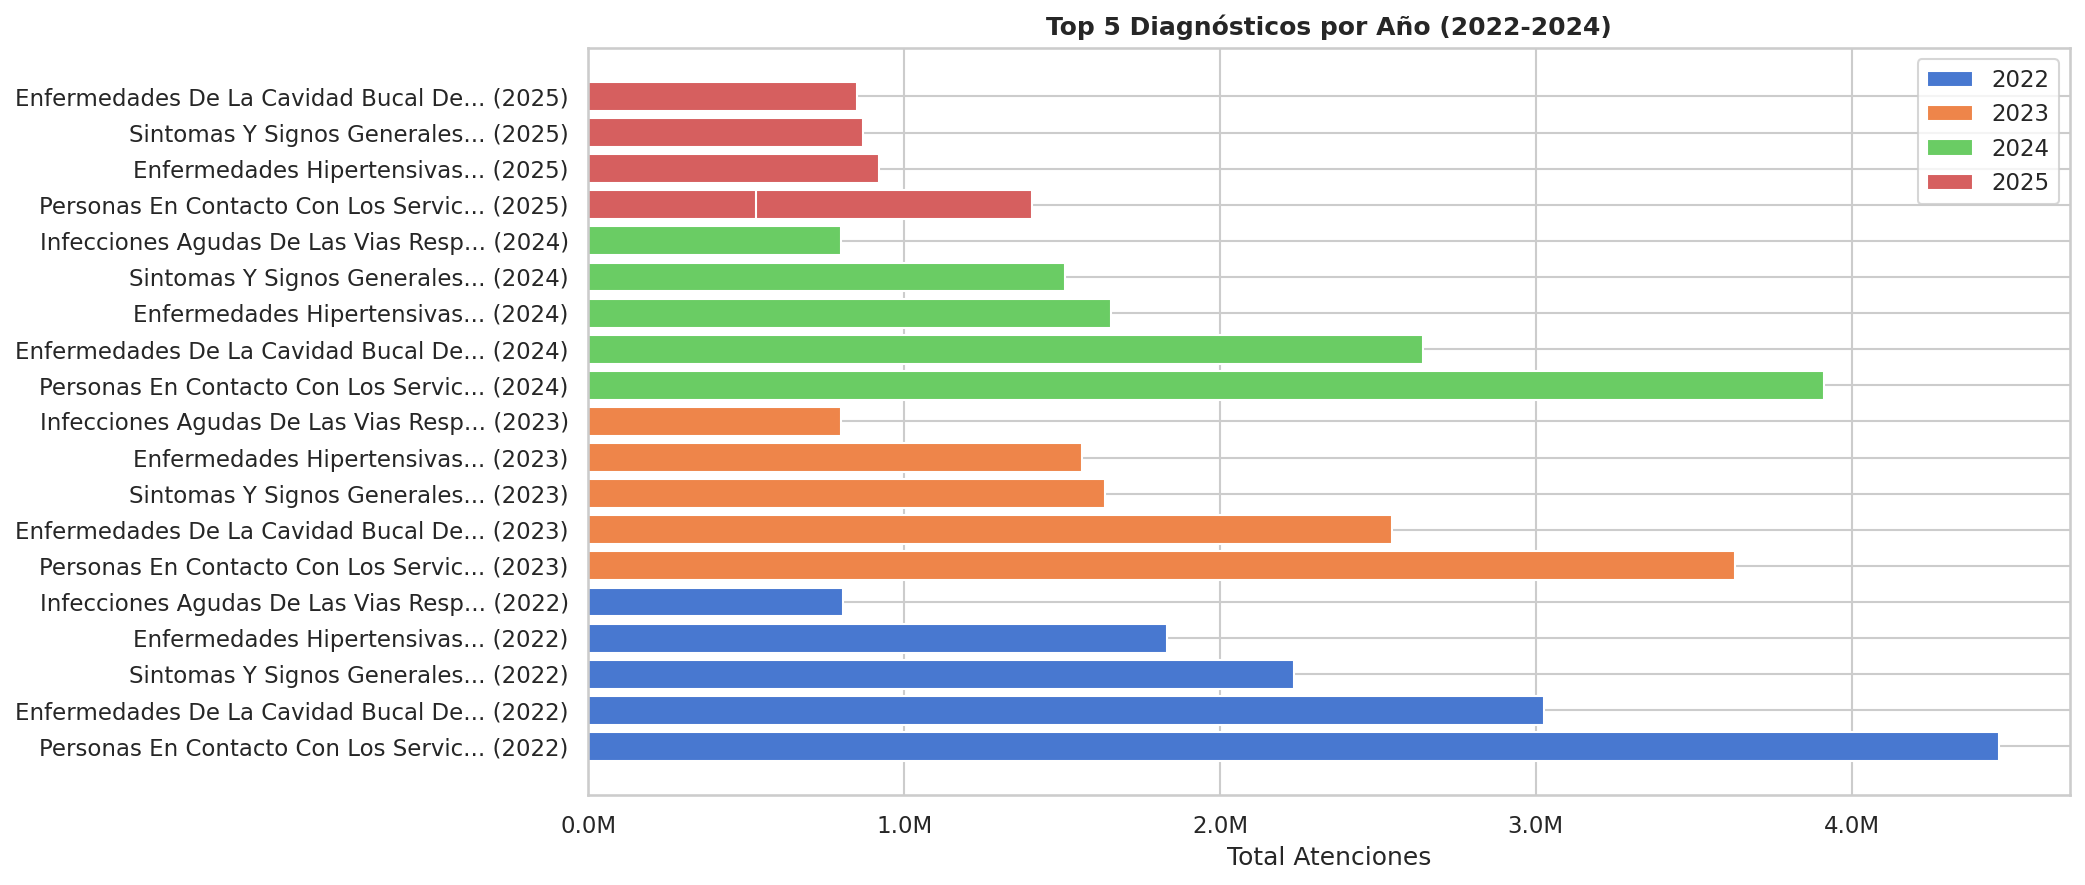

✅ Gráfica 1 guardada


In [ ]:
# ============================================================
# GRÁFICA 1: Top 5 diagnósticos por año
# ============================================================

top5 = df_q1.groupby('ANO').head(5).copy()
top5['diagnostico_corto'] = top5['diagnostico'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(14, 6))
for ano, grupo in top5.groupby('ANO'):
    ax.barh(grupo['diagnostico_corto'] + f' ({ano})',
            grupo['total_atenciones'], label=str(ano))
ax.set_title('Top 5 Diagnósticos por Año (2022-2024)')
ax.set_xlabel('Total Atenciones')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('/content/graficas/g1_top_diagnosticos.png')
plt.show()
print('✅ Gráfica 1 guardada')

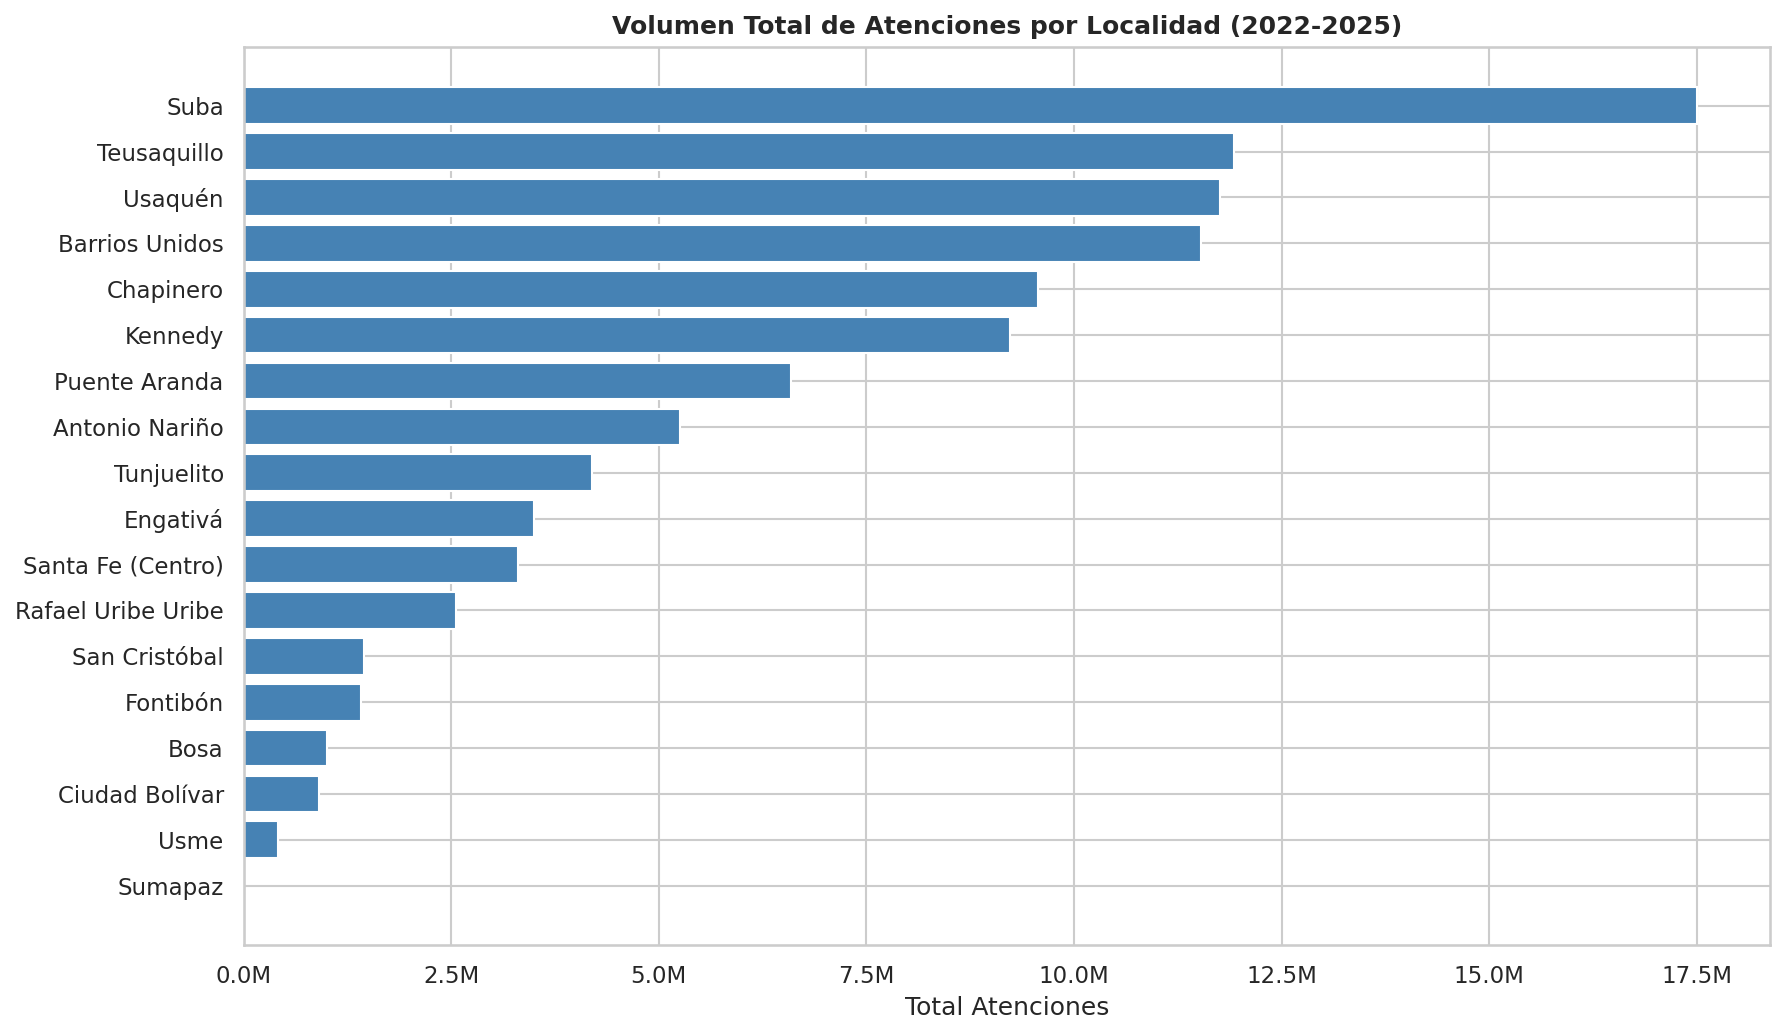

✅ Gráfica 2 guardada


In [ ]:
# ============================================================
# GRÁFICA 2: Volumen de atenciones por localidad
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))
df_q2_sorted = df_q2.sort_values('total_atenciones')
ax.barh(df_q2_sorted['localidad'], df_q2_sorted['total_atenciones'], color='steelblue')
ax.set_title('Volumen Total de Atenciones por Localidad (2022-2025)')
ax.set_xlabel('Total Atenciones')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('/content/graficas/g2_volumen_localidad.png')
plt.show()
print('✅ Gráfica 2 guardada')

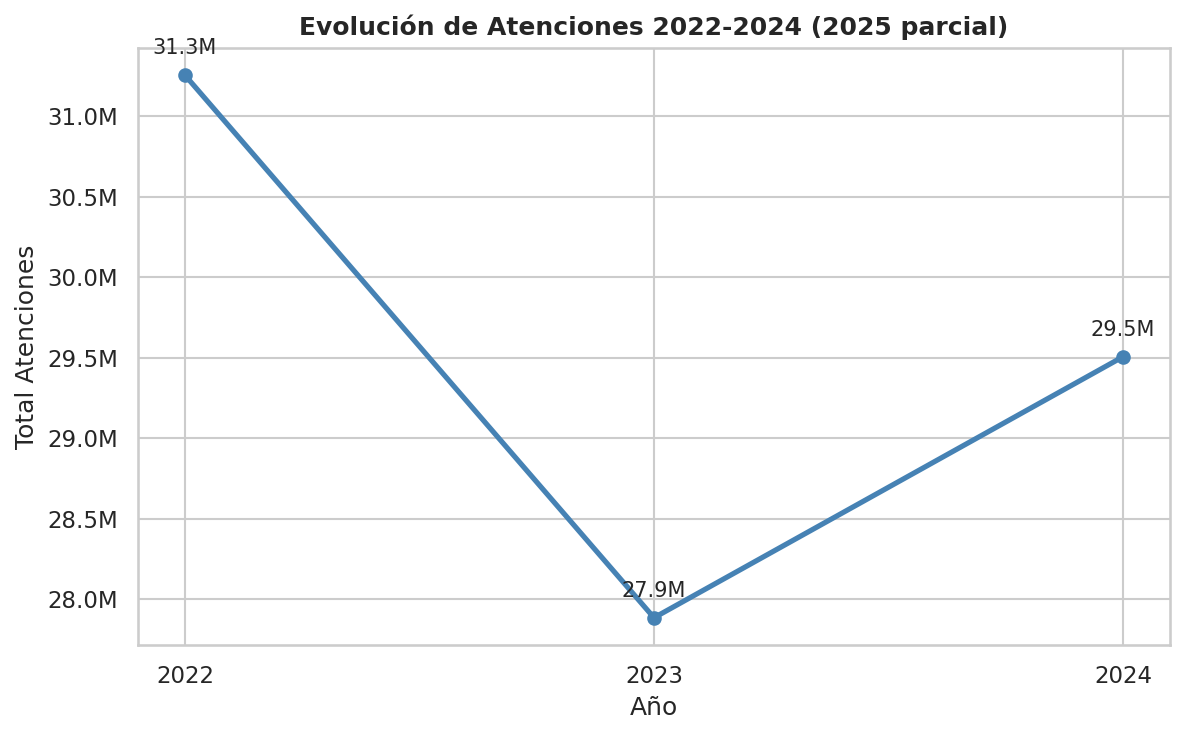

✅ Gráfica 3 guardada


In [ ]:
# ============================================================
# GRÁFICA 3: Evolución anual
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
df_q3_completo = df_q3[df_q3['ANO'] != 2025]
ax.plot(df_q3_completo['ANO'], df_q3_completo['total_atenciones'],
        marker='o', linewidth=2.5, color='steelblue')
ax.set_title('Evolución de Atenciones 2022-2024 (2025 parcial)')
ax.set_xlabel('Año')
ax.set_ylabel('Total Atenciones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xticks([2022, 2023, 2024])
for _, row in df_q3_completo.iterrows():
    ax.annotate(f'{row["total_atenciones"]/1e6:.1f}M',
                (row['ANO'], row['total_atenciones']),
                textcoords='offset points', xytext=(0, 10), ha='center')
plt.tight_layout()
plt.savefig('/content/graficas/g3_evolucion_anual.png')
plt.show()
print('✅ Gráfica 3 guardada')

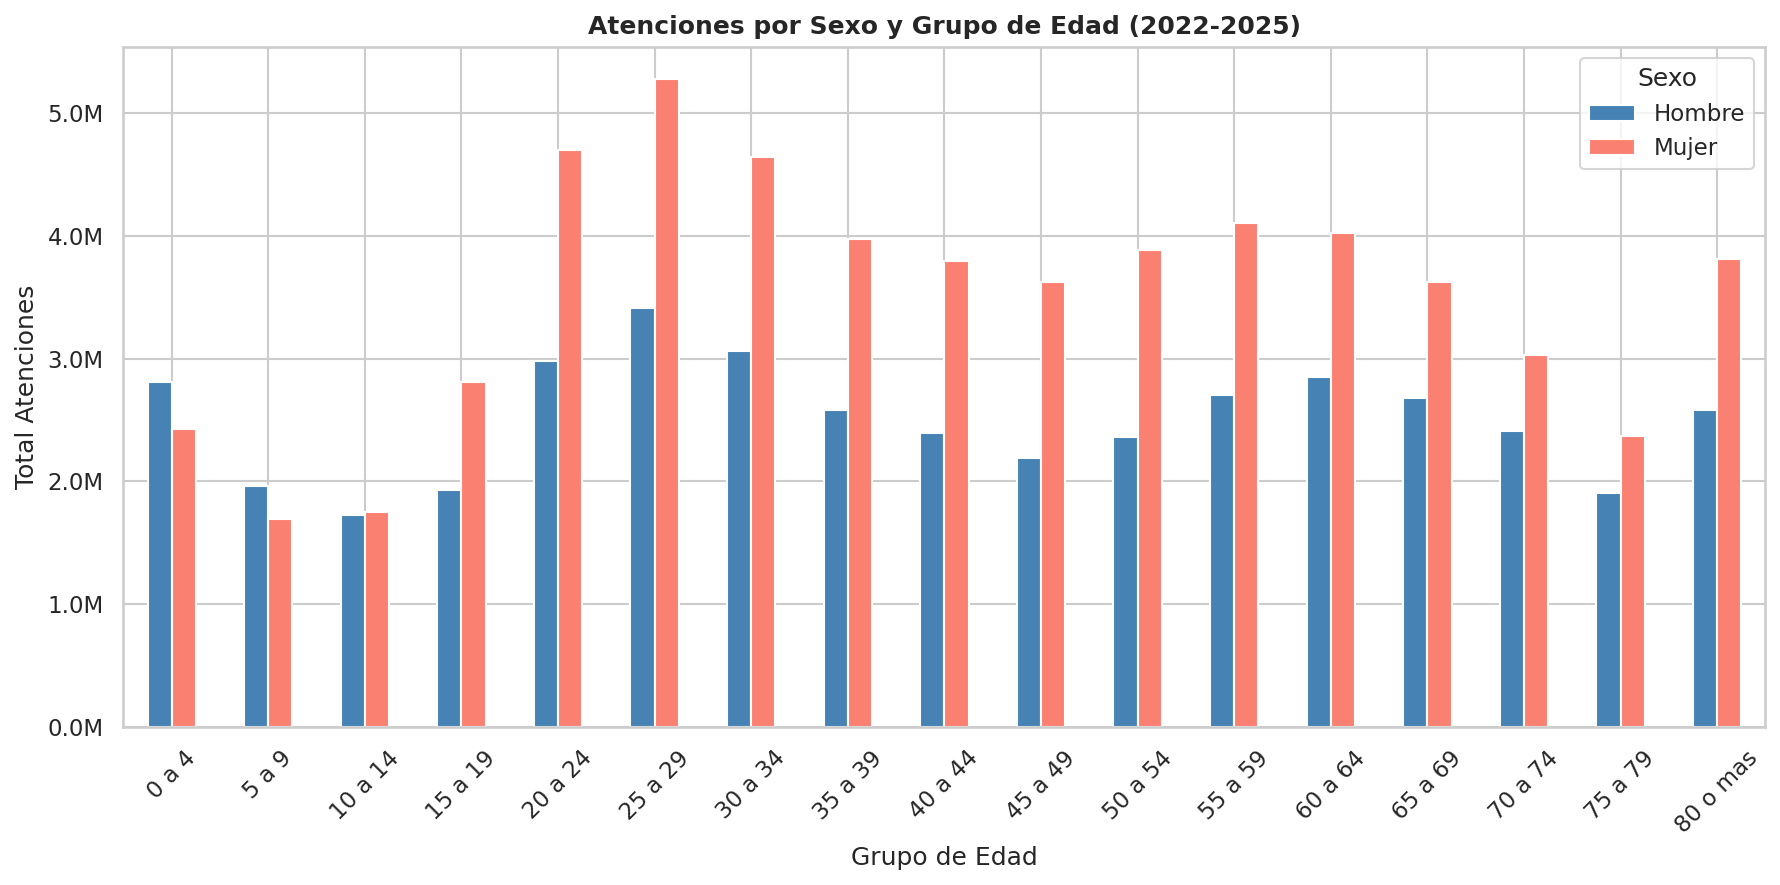

✅ Gráfica 4 guardada


In [ ]:
# ============================================================
# GRÁFICA 4: Atenciones por sexo y grupo de edad
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
df_q4_pivot = df_q4.pivot(index='grupo_edad', columns='sexo', values='total_atenciones')
orden_edad = ['0 a 4','5 a 9','10 a 14','15 a 19','20 a 24','25 a 29',
              '30 a 34','35 a 39','40 a 44','45 a 49','50 a 54',
              '55 a 59','60 a 64','65 a 69','70 a 74','75 a 79','80 o mas']
df_q4_pivot = df_q4_pivot.reindex(orden_edad)
df_q4_pivot.plot(kind='bar', ax=ax, color=['steelblue','salmon'])
ax.set_title('Atenciones por Sexo y Grupo de Edad (2022-2025)')
ax.set_xlabel('Grupo de Edad')
ax.set_ylabel('Total Atenciones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Sexo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/graficas/g4_sexo_edad.png')
plt.show()
print('✅ Gráfica 4 guardada')

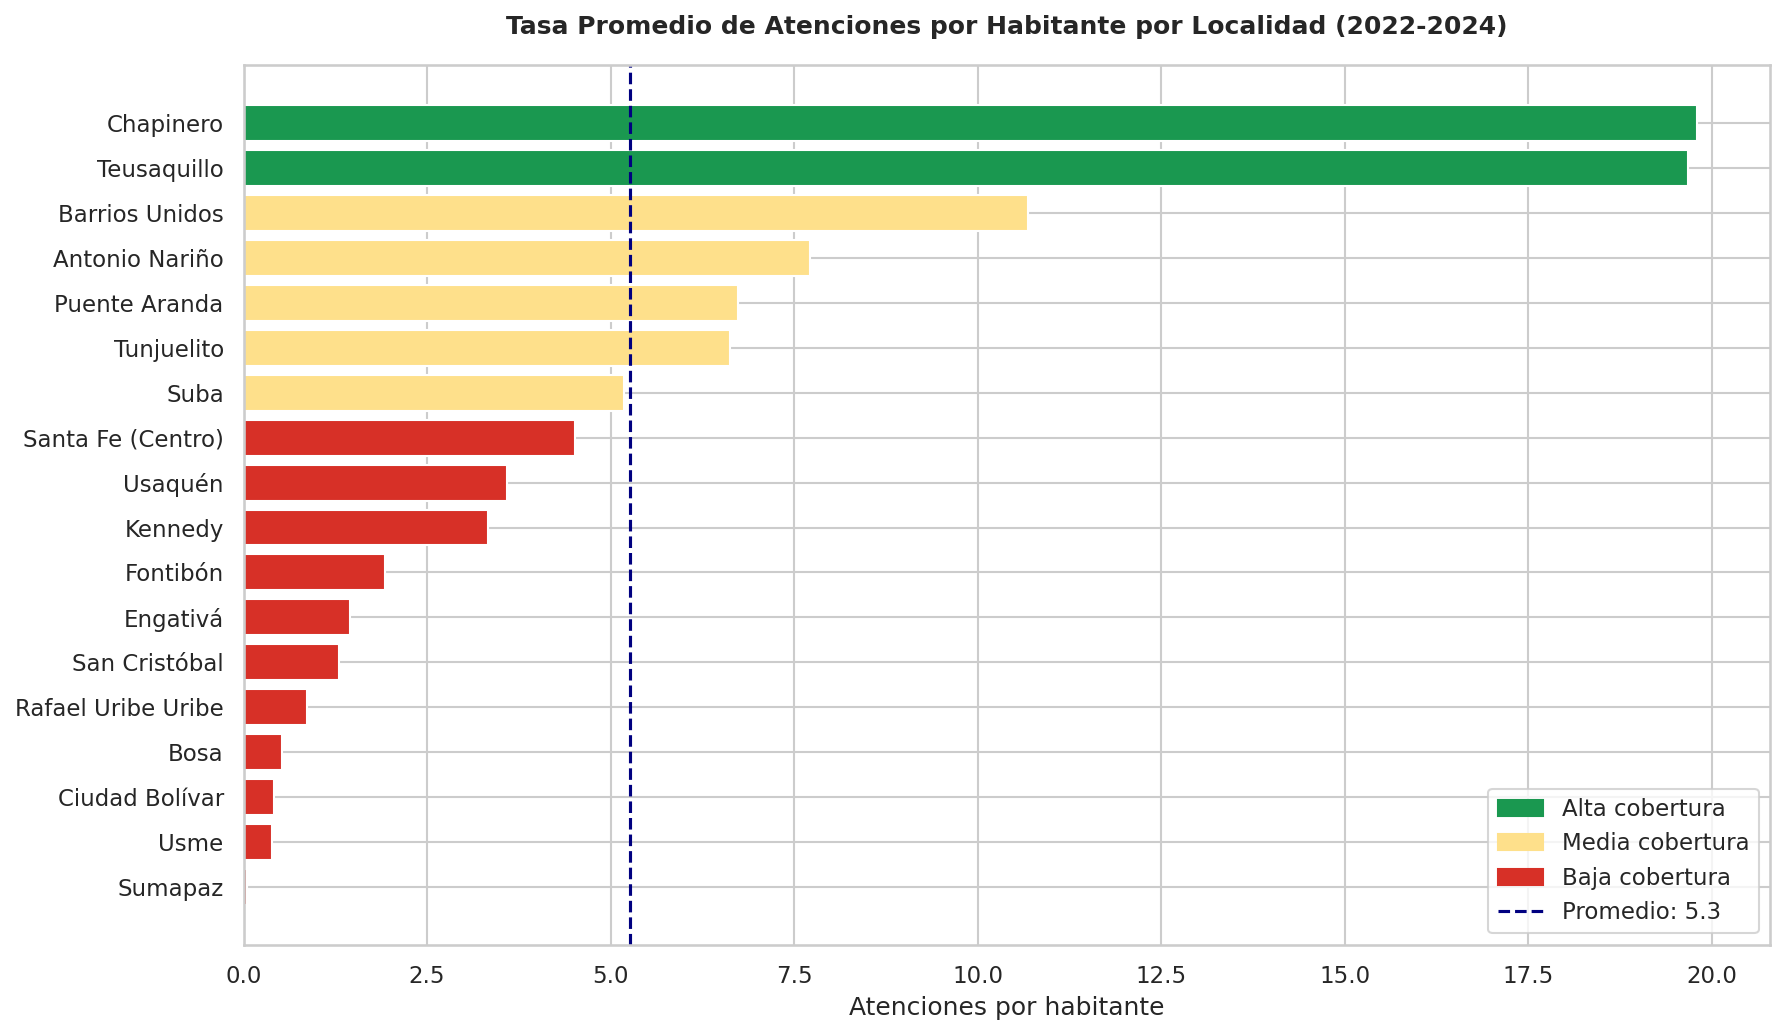

✅ Gráfica 5 guardada


In [ ]:
# ============================================================
# GRÁFICA 5: Tasa por habitante por localidad
# ============================================================

df_q5_avg = df_q5.groupby('localidad')['tasa_atenciones_por_habitante'].mean().sort_values()
colores = ['#d73027' if v < 5 else '#fee08b' if v < 15 else '#1a9850'
           for v in df_q5_avg.values]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_q5_avg.index, df_q5_avg.values, color=colores)
ax.axvline(df_q5_avg.mean(), color='navy', linestyle='--',
           label=f'Promedio: {df_q5_avg.mean():.1f}')
ax.set_title('Tasa Promedio de Atenciones por Habitante por Localidad (2022-2024)',
             pad=15)
ax.set_xlabel('Atenciones por habitante')
ax.legend()

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [Patch(color='#1a9850', label='Alta cobertura'),
           Patch(color='#fee08b', label='Media cobertura'),
           Patch(color='#d73027', label='Baja cobertura')]
ax.legend(handles=leyenda + [plt.Line2D([0],[0], color='navy',
          linestyle='--', label=f'Promedio: {df_q5_avg.mean():.1f}')],
          loc='lower right')

plt.tight_layout()
plt.savefig('/content/graficas/g5_tasa_habitante.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 5 guardada')

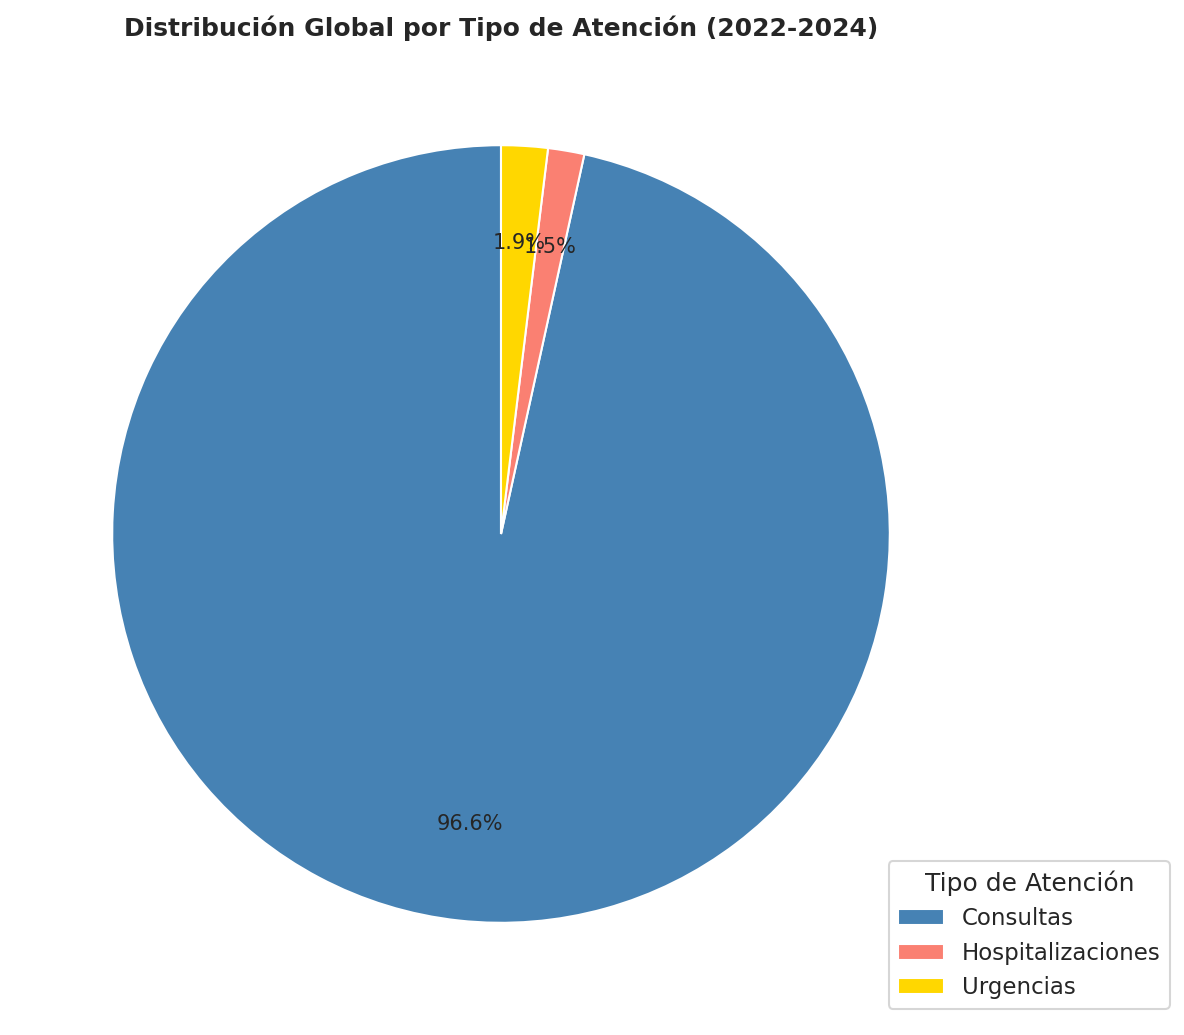

✅ Gráfica 6 guardada


In [ ]:
# =====================================
# GRÁFICA 6: Tipo de atención global
# ====================================

df_q7_global = df_q7.groupby('tipo_atencion')['total_atenciones'].sum()

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    df_q7_global.values,
    labels=None,
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon', 'gold'],
    startangle=90,
    pctdistance=0.75
)
ax.legend(wedges, df_q7_global.index,
          title='Tipo de Atención',
          loc='lower right',
          bbox_to_anchor=(1.2, 0))
ax.set_title('Distribución Global por Tipo de Atención (2022-2024)')
plt.tight_layout()
plt.savefig('/content/graficas/g6_tipo_atencion.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 6 guardada')

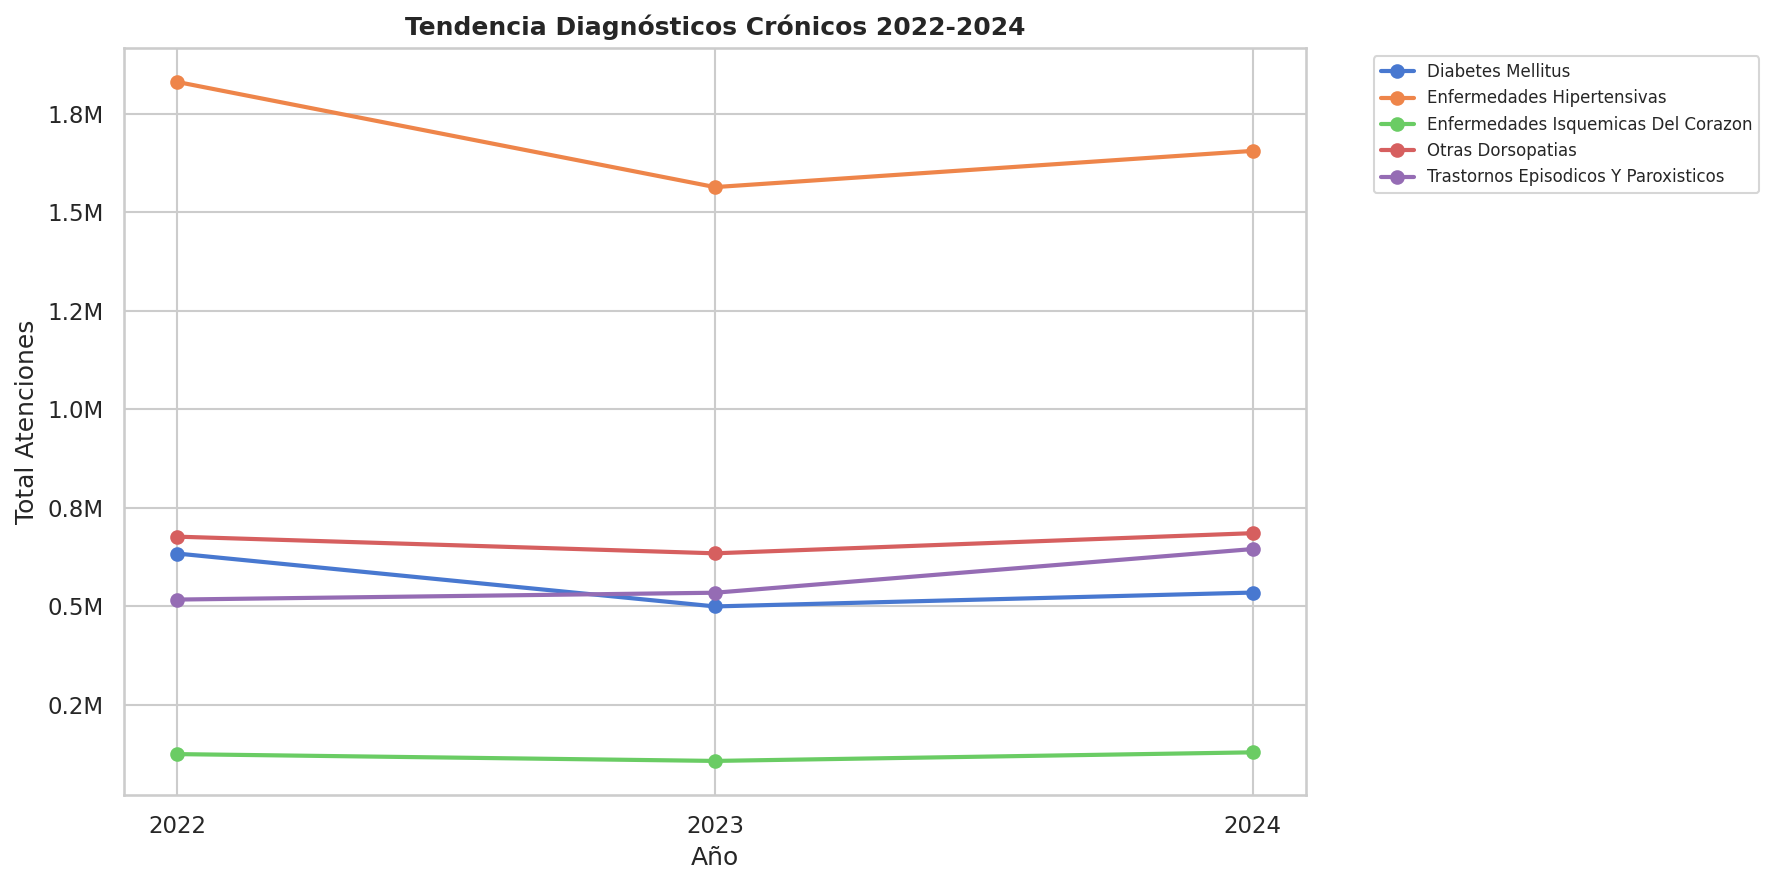

✅ Gráfica 7 guardada


In [ ]:
# ============================================================
# GRÁFICA 7: Tendencia diagnósticos crónicos
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
for dx, grupo in df_q9.groupby('diagnostico'):
    ax.plot(grupo['ANO'], grupo['total_atenciones'],
            marker='o', label=dx[:40], linewidth=2)
ax.set_title('Tendencia Diagnósticos Crónicos 2022-2024')
ax.set_xlabel('Año')
ax.set_ylabel('Total Atenciones')
ax.set_xticks([2022, 2023, 2024])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/graficas/g7_cronicos.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 7 guardada')

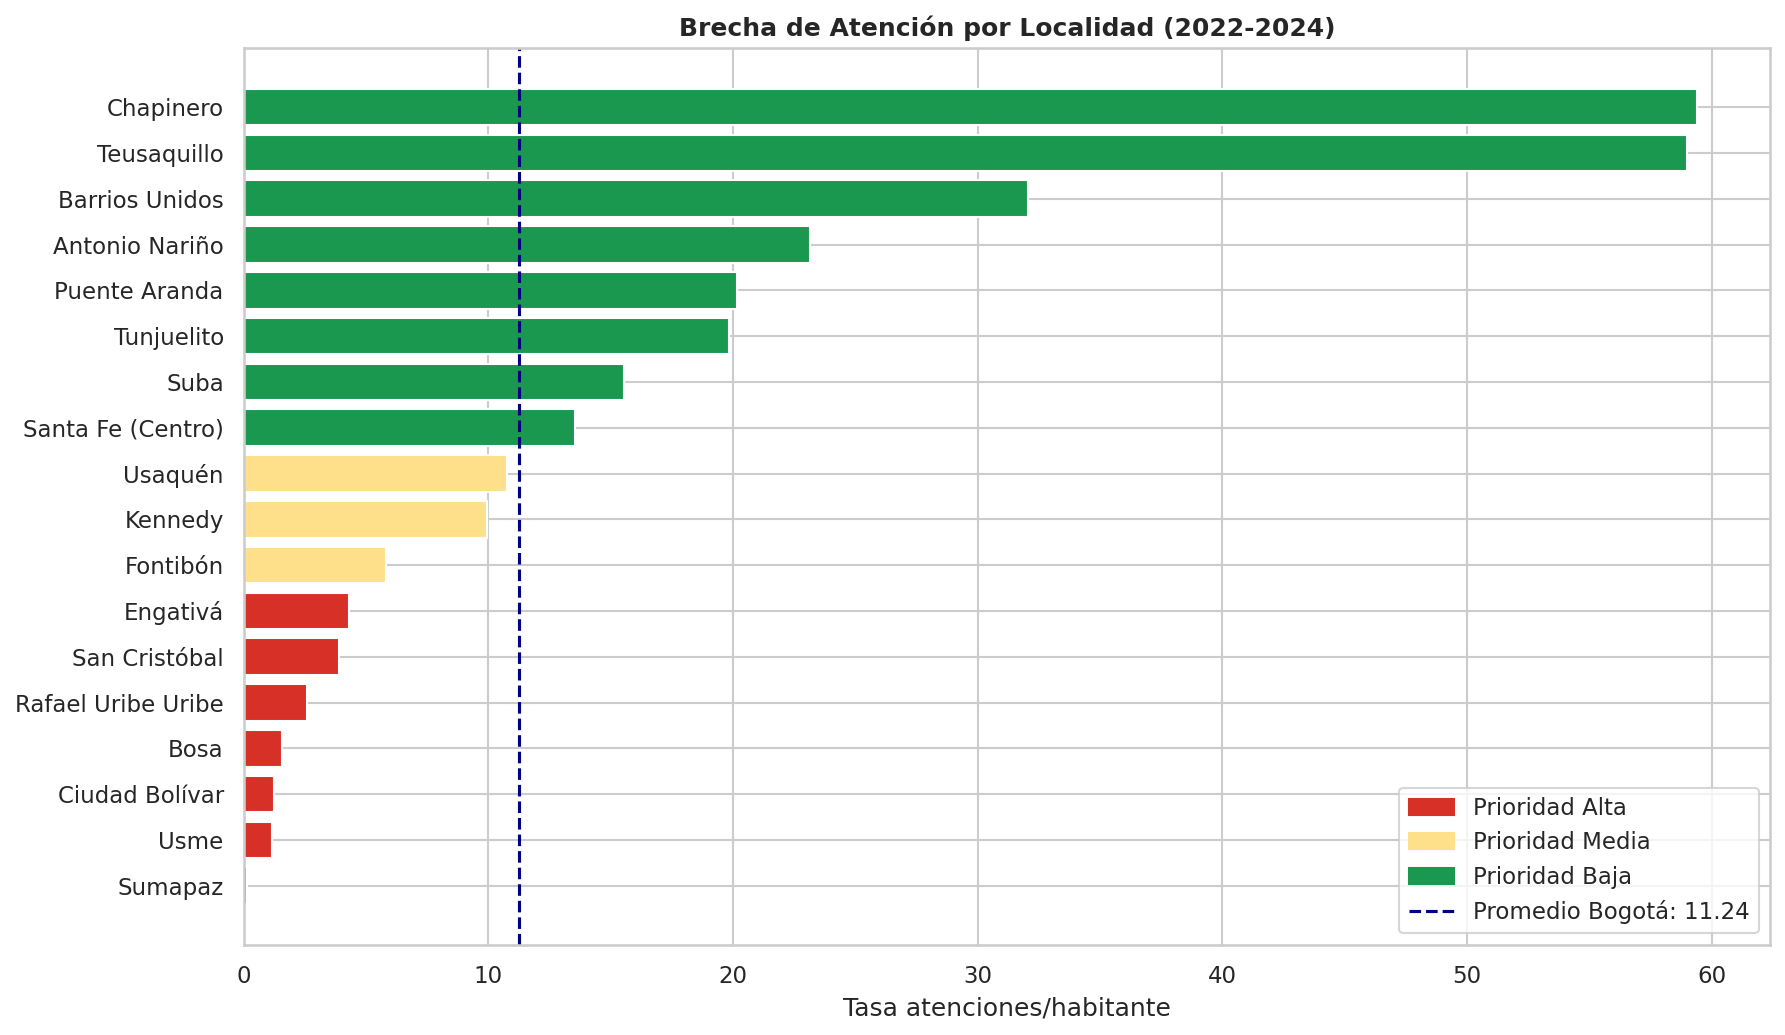

✅ Gráfica 8 guardada


In [ ]:
# ============================================================
# GRÁFICA 8: Brecha de atención por localidad
# ============================================================

from matplotlib.patches import Patch

df_q13_sorted = df_q13.sort_values('tasa_promedio')
colores_brecha = {'🔴 Alta': '#d73027', '🟡 Media': '#fee08b', '🟢 Baja': '#1a9850'}

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_q13_sorted['localidad'],
        df_q13_sorted['tasa_promedio'],
        color=[colores_brecha[p] for p in df_q13_sorted['prioridad']])
ax.axvline(11.24, color='navy', linestyle='--', label='Promedio Bogotá: 11.24')
ax.set_title('Brecha de Atención por Localidad (2022-2024)')
ax.set_xlabel('Tasa atenciones/habitante')

leyenda = [
    Patch(color='#d73027', label='Prioridad Alta'),
    Patch(color='#fee08b', label='Prioridad Media'),
    Patch(color='#1a9850', label='Prioridad Baja'),
    plt.Line2D([0],[0], color='navy', linestyle='--', label='Promedio Bogotá: 11.24')
]
ax.legend(handles=leyenda, loc='lower right')
plt.tight_layout()
plt.savefig('/content/graficas/g8_brecha.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 8 guardada')

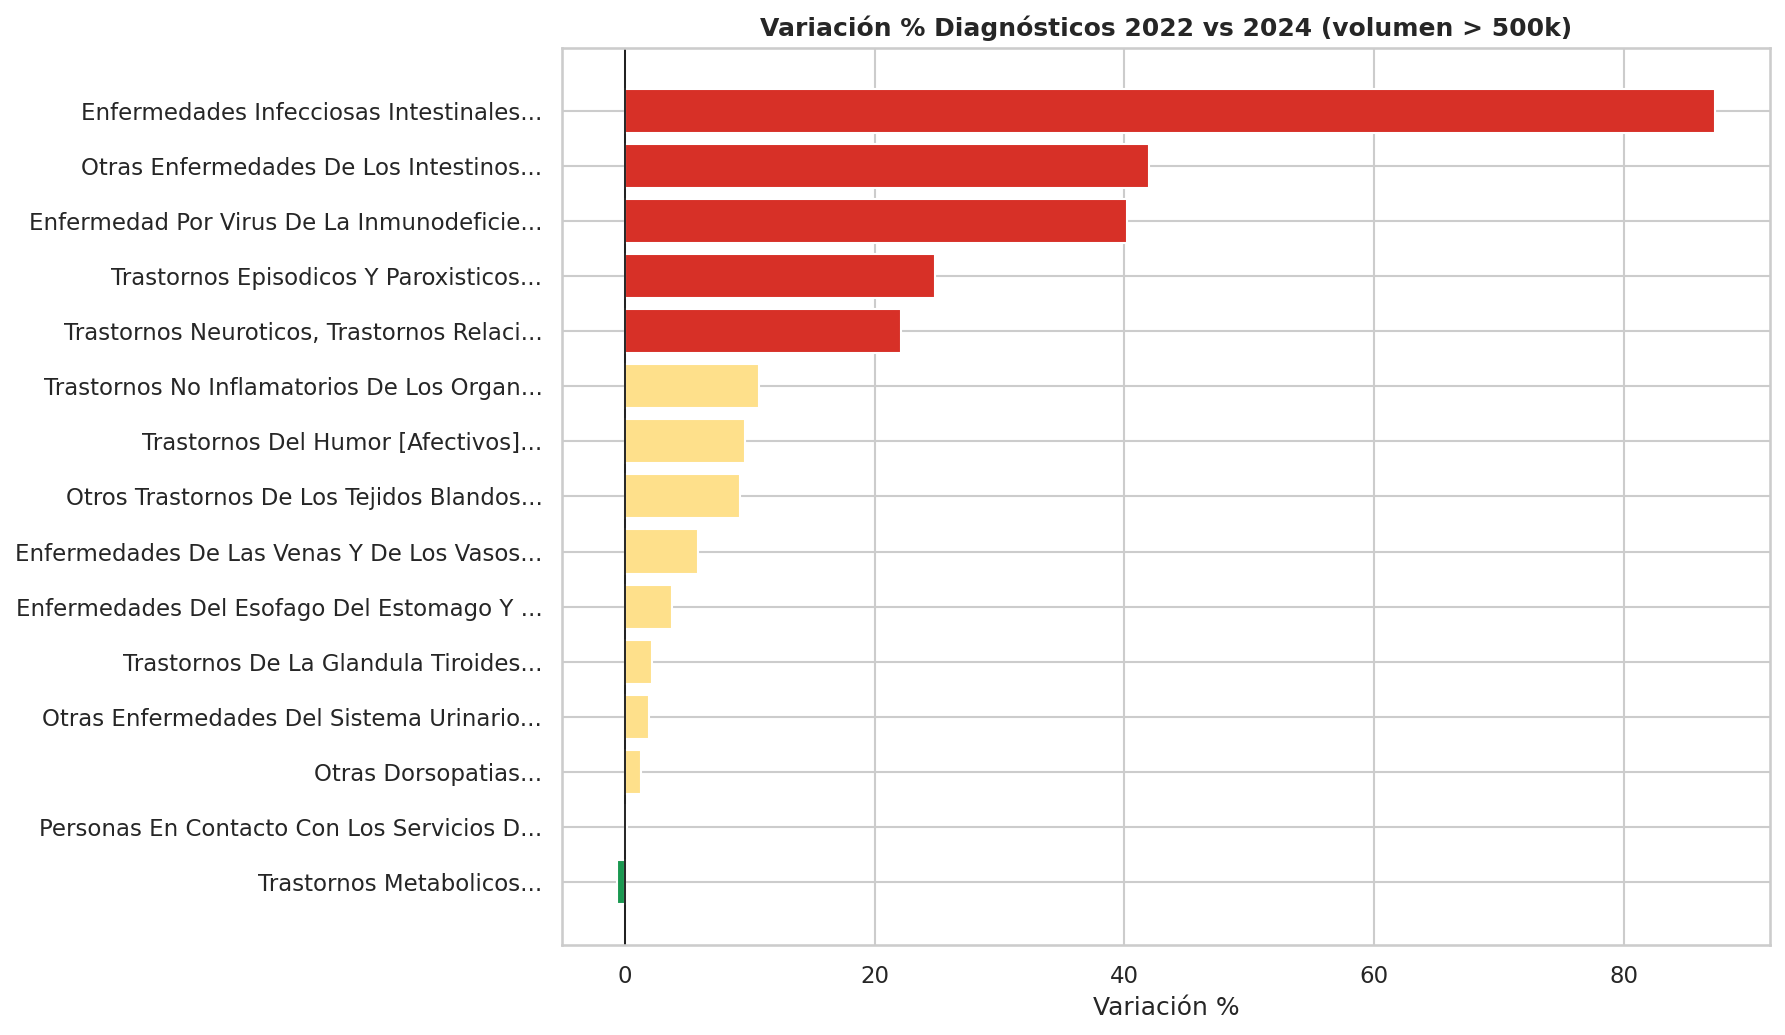

✅ Gráfica 9 guardada


In [ ]:
# ============================================================
# GRÁFICA 9: Diagnósticos con mayor crecimiento
# ============================================================

df_q14['diagnostico_corto'] = df_q14['diagnostico'].str[:40] + '...'
df_q14_sorted = df_q14.sort_values('var_pct_22_24')

colores_var = ['#d73027' if v > 20 else '#fee08b' if v > 0 else '#1a9850'
               for v in df_q14_sorted['var_pct_22_24']]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_q14_sorted['diagnostico_corto'],
        df_q14_sorted['var_pct_22_24'], color=colores_var)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variación % Diagnósticos 2022 vs 2024 (volumen > 500k)')
ax.set_xlabel('Variación %')
plt.tight_layout()
plt.savefig('/content/graficas/g9_diagnosticos_crecientes.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 9 guardada')

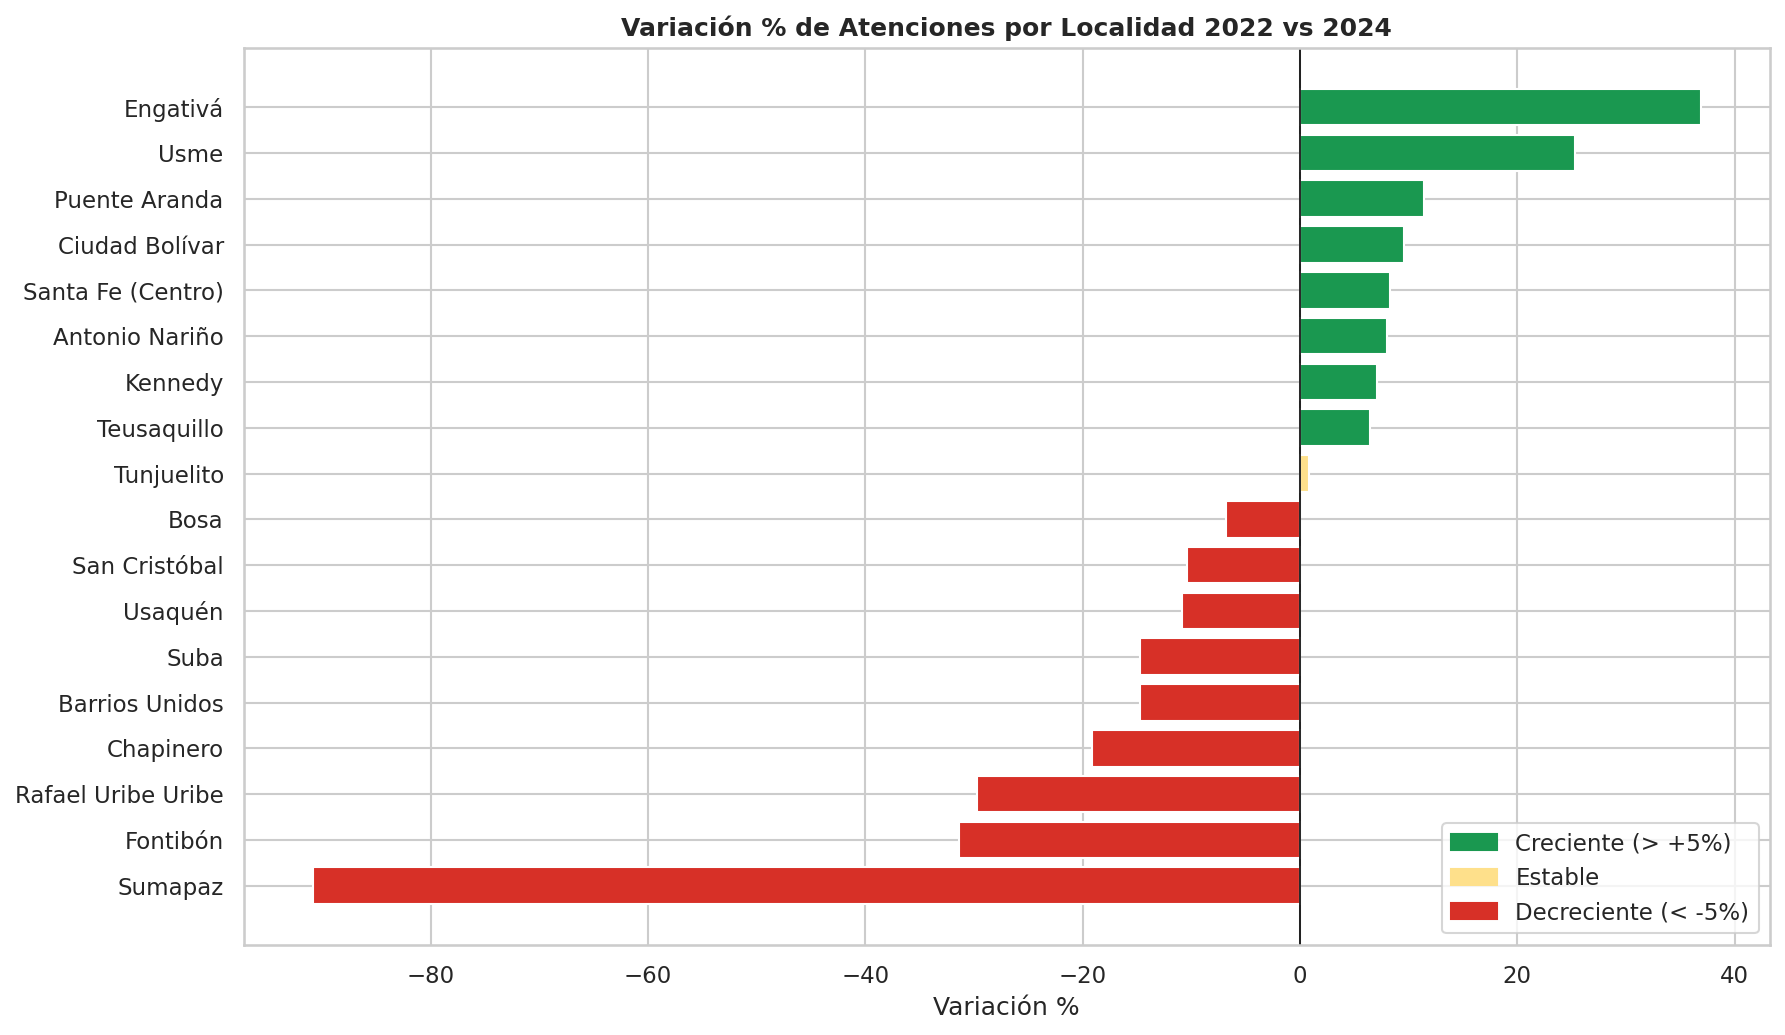

✅ Gráfica 10 guardada


In [ ]:
# ============================================================
# GRÁFICA 10: Tendencia por localidad 2022 vs 2024
# ============================================================

df_pivot10_reset = df_pivot10.reset_index()
df_pivot10_sorted = df_pivot10_reset.sort_values('var_pct_22_24')

colores_tend = ['#1a9850' if v > 5 else '#d73027' if v < -5 else '#fee08b'
                for v in df_pivot10_sorted['var_pct_22_24']]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_pivot10_sorted['localidad'],
        df_pivot10_sorted['var_pct_22_24'], color=colores_tend)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variación % de Atenciones por Localidad 2022 vs 2024')
ax.set_xlabel('Variación %')

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1a9850', label='Creciente (> +5%)'),
    Patch(color='#fee08b', label='Estable'),
    Patch(color='#d73027', label='Decreciente (< -5%)')
]
ax.legend(handles=leyenda, loc='lower right')
plt.tight_layout()
plt.savefig('/content/graficas/g10_tendencia_localidad.png', bbox_inches='tight')
plt.show()
print('✅ Gráfica 10 guardada')

In [ ]:
# ============================================================
# DESCARGAR TODAS LAS GRÁFICAS
# ============================================================

from google.colab import files
import os

ruta = '/content/graficas/'
for f in sorted(os.listdir(ruta)):
    print(f'Descargando {f}...')
    files.download(f'{ruta}{f}')

Descargando g10_tendencia_localidad.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando g1_top_diagnosticos.png...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando g9_diagnosticos_crecientes.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>